# Analysis used in paper
Notebook containing the analysis that led to the results and insights used in the paper.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import davies_bouldin_score
from scipy import stats
from scipy.stats import spearmanr, kendalltau, pearsonr
import statsmodels.stats.multicomp as mc
from kneed import KneeLocator

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

def q1(x):
    return x.quantile(0.25)

def q3(x):
    return x.quantile(0.75)

#### Reading in the data

In [2]:
data_respondents = pd.read_csv('../data/processed/data_for_analysis_respondents.csv')
data_respondents = data_respondents.drop(columns = ['Unnamed: 0'])
data_respondents_98_removed = pd.read_csv('../data/processed/data_for_analysis_respondents_98removed.csv')
data_respondents_98_removed = data_respondents_98_removed.drop(columns = ['Unnamed: 0'])

NG_data = pd.read_csv('../data/processed/data_for_analysis_NG_data.csv')
NG_data = NG_data.drop(columns = ['Unnamed: 0'])
NG_data = NG_data.loc[NG_data['person'] != '-'] # rows with respondents who didn't name anyone
country_order = ['UK', 'US', 'NL']
# Convert 'country' to a categorical variable with the custom order
NG_data['country'] = pd.Categorical(NG_data['country'], categories=country_order, ordered=True)
# Sort the DataFrame by the 'country' column
NG_data = NG_data.sort_values(['country', 'ID', 'person'])

### Brief overview of the data

##### Respondent data

In [3]:
data_respondents.head()

,country,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
0,NL,0,1,3.0,1.0,0,6,98.0,2,0.0,1,0,0.0,99.0,2.0,3.0,4.0,1.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0
1,NL,1,0,0.0,2.0,0,4,98.0,1,0.0,1,0,0.0,1.0,2.0,1.0,6.0,99.0,4.0,5.0,5.0,4.0,3.0,5.0,5.0
2,NL,2,0,0.0,0.0,0,2,98.0,1,0.0,1,0,0.0,99.0,2.0,1.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NL,3,0,0.0,0.0,0,1,98.0,1,0.0,1,0,0.0,99.0,3.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NL,4,1,3.0,0.0,0,2,98.0,1,0.0,1,0,0.0,99.0,3.0,98.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data_respondents.describe()

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
count,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,481.000000,481.000000,481.000000,481.000000,481.00000,481.000000,481.000000
mean,549.901058,0.509645,1.301805,1.518979,2.065339,13.303049,39.427505,3.490355,0.237710,0.426882,0.106409,478.016179,30.851276,4.122589,11.640946,4.221531,8.891724,3.272349,3.197505,3.301455,3.713098,3.85447,3.918919,3.530146
std,503.625202,0.500063,1.388133,5.706891,10.135942,30.113271,46.753010,13.073020,0.425813,0.494779,0.308457,856.310203,43.516544,11.094321,28.820782,1.554557,25.728528,1.030091,1.082279,1.077506,1.088201,1.07414,1.064423,1.183051
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
25%,202.500000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000
50%,389.000000,1.000000,1.000000,0.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,2.000000,5.000000,2.000000,3.000000,3.000000,3.000000,4.000000,4.00000,4.000000,4.000000
75%,686.000000,1.000000,3.000000,1.000000,1.000000,5.000000,98.000000,2.000000,0.000000,1.000000,0.000000,0.000000,99.000000,3.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,5.000000,5.00000,5.000000,5.000000
max,2255.000000,1.000000,3.000000,100.000000,200.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,2023.000000,99.000000,98.000000,98.000000,6.000000,99.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000


In [5]:
data_respondents.country.value_counts()

country
UK    741
US    448
NL    418
Name: count, dtype: int64

In [6]:
data_respondents_98_removed.describe()

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.0,923.000000,923.00000,923.000000,923.000000,923.000000,923.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000
mean,654.275190,0.533044,1.366197,1.985915,2.650054,2.721560,21.745395,1.686891,0.302275,0.204767,0.0,608.160347,3.23727,2.891658,2.154930,4.300108,1.563380,3.220859,3.131902,3.269939,3.693252,3.834356,3.904908,3.478528
std,533.775612,0.499177,1.391103,7.117606,11.970407,2.159939,38.731446,0.950232,0.459493,0.403750,0.0,924.508617,1.41844,0.831306,0.858064,1.501218,0.639484,1.031948,1.063128,1.087333,1.094497,1.082810,1.069942,1.178460
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,273.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,2.00000,2.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,509.000000,1.000000,1.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.0,0.000000,3.00000,3.000000,2.000000,5.000000,2.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000
75%,791.000000,1.000000,3.000000,2.000000,2.000000,4.000000,5.000000,2.000000,1.000000,0.000000,0.0,2003.000000,5.00000,4.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,4.000000
max,2253.000000,1.000000,3.000000,100.000000,200.000000,9.000000,98.000000,5.000000,1.000000,1.000000,0.0,2023.000000,5.00000,4.000000,4.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
data_respondents_98_removed.country.value_counts()

country
UK    509
US    335
NL     79
Name: count, dtype: int64

##### Name Generator data

In [8]:
NG_data.head()

,country,ID,person,Q29a_adapt,Q29b_who_family,Q29b_who_neighbor,Q29b_who_colleague,Q29b_who_online,Q29b_who_gov,Q29b_who_other,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age,Q29c_similar_none,Q29d_distance,Q29e_com_street,Q29e_com_call,Q29e_com_gatherings,Q29e_com_work,Q29e_com_other,Q29f_com_freq,Q29g_flood_com_freq,Q29h_com_what_cause,Q29h_com_what_measures,Q29h_com_what_community,Q29h_com_what_gov_react,Q29h_com_what_gov_adapt,Q29h_com_what_livability,Q29h_com_what_other,Q29i_worry,Q29j_valuable_exp
825,UK,2,1,98.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,5.0
826,UK,2,2,98.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,5.0
827,UK,2,3,98.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,98.0,0.0,0.0,0.0,0.0,1.0,5.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,98.0,3.0
830,UK,5,1,98.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,1.0,4.0
831,UK,5,2,98.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,1.0,3.0


In [9]:
NG_data.describe()

,ID,Q29a_adapt,Q29b_who_family,Q29b_who_neighbor,Q29b_who_colleague,Q29b_who_online,Q29b_who_gov,Q29b_who_other,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age,Q29c_similar_none,Q29d_distance,Q29e_com_street,Q29e_com_call,Q29e_com_gatherings,Q29e_com_work,Q29e_com_other,Q29f_com_freq,Q29g_flood_com_freq,Q29h_com_what_cause,Q29h_com_what_measures,Q29h_com_what_community,Q29h_com_what_gov_react,Q29h_com_what_gov_adapt,Q29h_com_what_livability,Q29h_com_what_other,Q29i_worry,Q29j_valuable_exp
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,0.0,2100.000000,2100.000000
mean,594.437143,28.528095,0.618571,0.173333,0.118095,0.060476,0.049524,0.169048,0.372381,0.340000,0.352857,0.236667,0.333810,0.310476,17.262381,0.206667,0.426667,0.374762,0.107143,0.261905,1.975714,3.564286,0.496667,0.222381,0.171429,0.249048,0.182857,0.332381,NaN,14.983810,2.846667
std,515.301497,44.360188,0.485853,0.378625,0.322798,0.238424,0.217011,0.374883,0.483554,0.473822,0.477973,0.425137,0.471685,0.462799,34.456554,0.405011,0.494711,0.484177,0.309368,0.439776,1.468708,1.321267,0.500108,0.415945,0.376973,0.432564,0.386641,0.471179,NaN,32.723213,1.387109
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000
25%,225.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,2.000000
50%,419.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,3.000000
75%,739.000000,98.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,5.000000,0.000000,1.000000,1.000000,0.000000,1.000000,3.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,4.000000,4.000000
max,2255.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,98.000000,5.000000


In [10]:
NG_data.groupby('country').count()

,ID,person,Q29a_adapt,Q29b_who_family,Q29b_who_neighbor,Q29b_who_colleague,Q29b_who_online,Q29b_who_gov,Q29b_who_other,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age,Q29c_similar_none,Q29d_distance,Q29e_com_street,Q29e_com_call,Q29e_com_gatherings,Q29e_com_work,Q29e_com_other,Q29f_com_freq,Q29g_flood_com_freq,Q29h_com_what_cause,Q29h_com_what_measures,Q29h_com_what_community,Q29h_com_what_gov_react,Q29h_com_what_gov_adapt,Q29h_com_what_livability,Q29h_com_what_other,Q29i_worry,Q29j_valuable_exp
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
UK,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,868,0,868,868
US,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,668,0,668,668
NL,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,0,564,564


In [11]:
NG_data.groupby(['country', 'person']).count()

ID  Q29a_adapt  Q29b_who_family  Q29b_who_neighbor  \
country person                                                        
UK      1       336         336              336                336   
        2       287         287              287                287   
        3       245         245              245                245   
US      1       262         262              262                262   
        2       216         216              216                216   
        3       190         190              190                190   
NL      1       225         225              225                225   
        2       178         178              178                178   
        3       161         161              161                161   

                Q29b_who_colleague  Q29b_who_online  Q29b_who_gov  \
country person                                                      
UK      1                      336              336           336   
        2                      287              287           287   
        3                      245              245           245   
US      1                      262              262           262   
        2                      216              216           216   
        3                      190              190           190   
NL      1                      225              225           225   
        2                      178              178           178   
        3                      161              161           161   

                Q29b_who_other  Q29c_similar_flood  Q29c_similar_house  \
country person                                                           
UK      1                  336                 336                 336   
        2                  287                 287                 287   
        3                  245                 245                 245   
US      1                  262                 262                 262   
        2                  216                 216                 216   
        3                  190                 190                 190   
NL      1                  225                 225                 225   
        2                  178                 178                 178   
        3                  161                 161                 161   

                Q29c_similar_edu  Q29c_similar_inc  Q29c_similar_age  \
country person                                                         
UK      1                    336               336               336   
        2                    287               287               287   
        3                    245               245               245   
US      1                    262               262               262   
        2                    216               216               216   
        3                    190               190               190   
NL      1                    225               225               225   
        2                    178               178               178   
        3                    161               161               161   

                Q29c_similar_none  Q29d_distance  Q29e_com_street  \
country person                                                      
UK      1                     336            336              336   
        2                     287            287              287   
        3                     245            245              245   
US      1                     262            262              262   
        2                     216            216              216   
        3                     190            190              190   
NL      1                     225            225              225   
        2                     178            178              178   
        3                     161            161              161   

                Q29e_com_call  Q29e_com_gatherings  Q29e_com_work  \
country person                        

## Descriptive statistics of the variables used
This is mainly for the appendix of the paper.

In [12]:
# separating the data for each country
data_respondents_NL = data_respondents.loc[data_respondents['country'] == 'NL']
data_respondents_UK = data_respondents.loc[data_respondents['country'] == 'UK']
data_respondents_US = data_respondents.loc[data_respondents['country'] == 'US']

##### For N and statistics regarding the discussion frquency and flood experience

In [13]:
data_respondents_NL.describe()

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.0,418.000000,418.000000,418.0,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,209.712919,0.533493,1.334928,1.057416,1.066986,15.038278,98.0,5.990431,0.052632,1.0,0.131579,105.569378,64.519139,2.653110,26.550239,3.842105,27.196172,3.429825,3.280702,3.280702,3.412281,3.622807,3.850877,3.605263
std,121.295342,0.499475,1.386047,2.853170,5.860923,32.375472,0.0,20.121928,0.223564,0.0,0.338438,448.445732,46.391472,0.811637,42.490497,1.677599,42.970569,1.167171,1.208442,1.300162,1.260786,1.229363,1.161571,1.259431
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,98.0,1.000000,0.000000,1.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,105.250000,0.000000,0.000000,0.000000,0.000000,1.000000,98.0,1.000000,0.000000,1.0,0.000000,0.000000,3.000000,2.000000,1.000000,2.000000,1.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000
50%,209.500000,1.000000,1.000000,0.000000,0.000000,2.000000,98.0,1.000000,0.000000,1.0,0.000000,0.000000,99.000000,3.000000,1.000000,4.000000,2.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000
75%,314.750000,1.000000,3.000000,1.000000,0.000000,5.000000,98.0,2.000000,0.000000,1.0,0.000000,0.000000,99.000000,3.000000,98.000000,5.000000,99.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000
max,419.000000,1.000000,3.000000,25.000000,99.000000,98.000000,98.0,98.000000,1.000000,1.0,1.000000,2022.000000,99.000000,4.000000,98.000000,6.000000,99.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [14]:
data_respondents_UK.describe()

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
count,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,375.264507,0.450742,1.165992,1.581646,1.886640,10.170040,21.352227,3.022942,0.180837,0.236167,0.078273,362.387314,21.149798,5.682861,7.730094,4.170040,3.013495,3.297297,3.135135,3.281081,3.875676,4.000000,3.935135,3.540541
std,217.494492,0.497904,1.375747,7.501379,9.685631,26.369787,38.494841,11.701386,0.385143,0.425013,0.268782,771.850967,37.292061,16.182008,22.708375,1.594151,11.804481,0.985351,1.036354,0.976306,1.011189,1.058095,1.111261,1.246617
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,188.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,375.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,2.000000,5.000000,2.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000
75%,563.000000,1.000000,3.000000,0.000000,1.000000,4.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000
max,750.000000,1.000000,3.000000,100.000000,150.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,2023.000000,99.000000,98.000000,98.000000,6.000000,99.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [15]:
data_respondents_US.describe()

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
count,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,1156.160714,0.584821,1.495536,1.845982,3.292411,16.866071,14.674107,1.930804,0.504464,0.207589,0.129464,1016.774554,15.484375,2.912946,4.198661,4.660714,1.535714,3.148352,3.208791,3.335165,3.736264,3.851648,3.945055,3.472527
std,540.459645,0.493304,1.388665,3.993948,13.389426,33.124332,32.192320,0.997598,0.500539,0.406034,0.336088,1008.888342,32.265256,0.765014,12.556389,1.231965,0.499280,0.971968,1.046082,1.026055,1.011920,0.960532,0.950285,1.065176
min,272.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,689.750000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,4.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,1133.500000,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1969.500000,3.000000,3.000000,3.000000,5.000000,2.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.500000
75%,1548.750000,1.000000,3.000000,2.000000,3.000000,7.000000,4.000000,2.000000,1.000000,0.000000,0.000000,2020.000000,5.000000,3.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000
max,2255.000000,1.000000,3.000000,30.000000,200.000000,98.000000,98.000000,5.000000,1.000000,1.000000,1.000000,2022.000000,99.000000,4.000000,97.000000,6.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [16]:
# counting I don't know or other or I don't want to say responses for worry and perc prob
print('NL')
print(data_respondents_NL['R02_perc_prob'].value_counts())
print(data_respondents_NL['R05_worry'].value_counts())
print()
print('UK')
print(data_respondents_UK['R02_perc_prob'].value_counts())
print(data_respondents_UK['R05_worry'].value_counts())
print()
print('US')
print(data_respondents_US['R02_perc_prob'].value_counts())
print(data_respondents_US['R05_worry'].value_counts())

NL
R02_perc_prob
1     151
2      88
98     55
3      41
5      28
4      23
6      17
7      11
9       3
8       1
Name: count, dtype: int64
R05_worry
1     240
2     102
3      37
98     19
4      13
5       7
Name: count, dtype: int64

UK
R02_perc_prob
1     351
2     145
98     58
3      41
6      38
5      37
4      34
7      24
8      10
97      3
Name: count, dtype: int64
R05_worry
1     443
2     195
3      53
4      25
5      14
98     11
Name: count, dtype: int64

US
R02_perc_prob
1     122
2      85
98     58
7      46
5      39
4      25
6      23
3      21
8      15
9       8
95      6
Name: count, dtype: int64
R05_worry
1    179
2    169
3     64
4     24
5     12
Name: count, dtype: int64


##### Getting statistics for reponses with IDK answers (worry, perc prob)

In [17]:
data_NL_perc_prob = data_respondents_NL[(data_respondents_NL.R02_perc_prob != 95) &
                                 (data_respondents_NL.R02_perc_prob != 98) & 
                                 (data_respondents_NL.R02_perc_prob != 97)]
data_NL_worry = data_respondents_NL[(data_respondents_NL.R05_worry != 98)]
print(data_NL_perc_prob.R02_perc_prob.describe())
print(data_NL_worry.R05_worry.describe())

count    363.000000
mean       2.468320
std        1.810334
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: R02_perc_prob, dtype: float64
count    399.000000
mean       1.609023
std        0.911963
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: R05_worry, dtype: float64


In [18]:
data_UK_perc_prob = data_respondents_UK[(data_respondents_UK.R02_perc_prob != 95) &
                                 (data_respondents_UK.R02_perc_prob != 98) & 
                                 (data_respondents_UK.R02_perc_prob != 97)]
data_UK_worry = data_respondents_UK[(data_respondents_UK.R05_worry != 98)]
print(data_UK_perc_prob.R02_perc_prob.describe())
print(data_UK_worry.R05_worry.describe())

count    680.000000
mean       2.295588
std        1.868106
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max        8.000000
Name: R02_perc_prob, dtype: float64
count    730.000000
mean       1.591781
std        0.907484
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: R05_worry, dtype: float64


In [19]:
data_US_perc_prob = data_respondents_US[(data_respondents_US.R02_perc_prob != 95) &
                                 (data_respondents_US.R02_perc_prob != 98) & 
                                 (data_respondents_US.R02_perc_prob != 97)]
data_US_worry = data_respondents_US[(data_respondents_US.R05_worry != 98)]
print(data_US_perc_prob.R02_perc_prob.describe())
print(data_US_worry.R05_worry.describe())

count    384.000000
mean       3.390625
std        2.451304
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max        9.000000
Name: R02_perc_prob, dtype: float64
count    448.000000
mean       1.930804
std        0.997598
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
Name: R05_worry, dtype: float64


#### Last flood experience
When did respondents last experience flooding (381 in total with flood experience)

Respondents with flood experience:  381


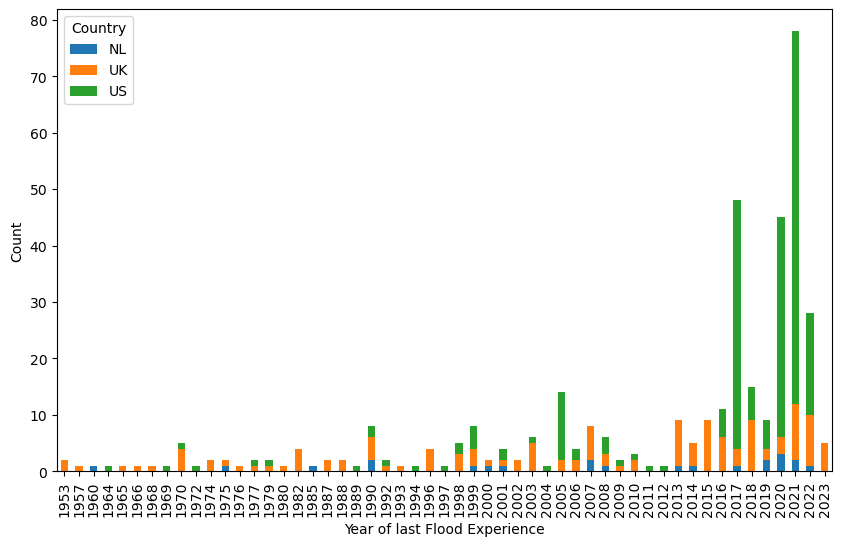

In [20]:
data_fl_exp_year = data_respondents[['country', 'Last_flood_exp_year']]
# Step 1: Filter out 0 - all those with no flood experience
df_filtered = data_fl_exp_year[data_fl_exp_year['Last_flood_exp_year'] > 1900]
df_filtered['Last_flood_exp_year'] = df_filtered['Last_flood_exp_year'].astype(int)
print('Respondents with flood experience: ', df_filtered.shape[0])
# Step 2: Group by year_experience and country, then count occurrences
grouped = df_filtered.groupby(['Last_flood_exp_year', 'country']).size().reset_index(name='count')

# Step 3: Pivot the data for stacked bar plot
pivot_df = grouped.pivot(index='Last_flood_exp_year', columns='country', values='count').fillna(0)

# Step 4: Plot the stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
           
#plt.title('Count of Year Flood Experience by Country')
plt.xlabel('Year of last Flood Experience')
plt.ylabel('Count')
plt.legend(title='Country')
plt.savefig('../reports/figures/year_last_flood_experience.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

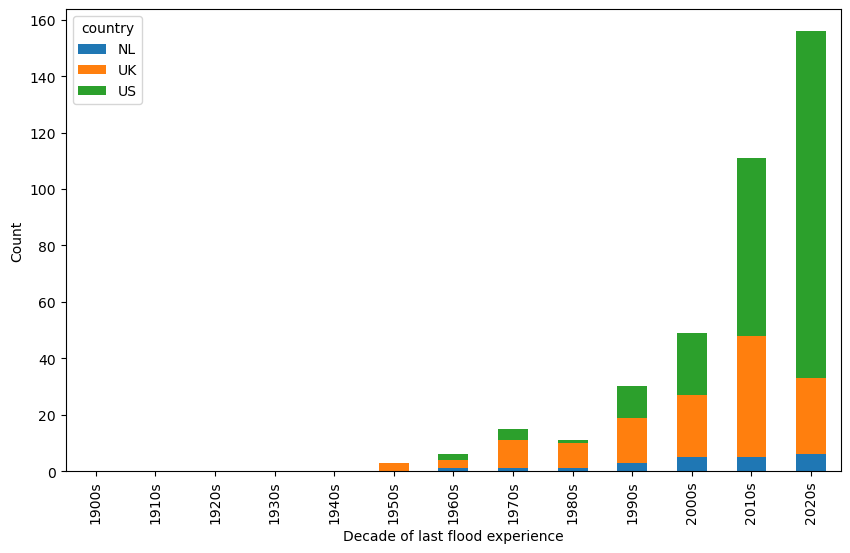

In [21]:
# Bin years into decades
df_filtered['decade'] = pd.cut(
    df_filtered['Last_flood_exp_year'],
    bins=range(1900, 2031, 10),
    right=False,
    labels=[f"{y}s" for y in range(1900, 2030, 10)]
)

# Group by decade and country
grouped = df_filtered.groupby(['decade', 'country']).size().reset_index(name='count')
pivot_df = grouped.pivot(index='decade', columns='country', values='count').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
#plt.title('Count of Year Experience by Country (Grouped by Decade)')
plt.ylabel('Count')
plt.xlabel('Decade of last flood experience')
plt.savefig('../reports/figures/year_last_flood_experience_decades.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

## RQ1: Intensity and thematic focus of social interactions
What is the intensity and the exact thematic focus of the social interactions about climate risks and adaptation?

In [22]:
data_discussions = data_respondents[['country', 'ID', 'Q28_convo_prob', 'Q28_convo_severity', 'Q28_convo_worry',
                                'Q28_convo_resp_efficacy', 'Q28_convo_costs', 'Q28_convo_community', 'Q28_convo_gov']]
data_discussions.head()

,country,ID,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov
0,NL,0,3.0,3.0,3.0,4.0,4.0,4.0,4.0
1,NL,1,4.0,5.0,5.0,4.0,3.0,5.0,5.0
2,NL,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NL,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NL,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
data_discussions = data_discussions.rename(columns={'Q28_convo_prob': 'Probability', 'Q28_convo_severity': 'Severity',
       'Q28_convo_worry': 'Worry', 'Q28_convo_resp_efficacy': 'Response_efficacy', 'Q28_convo_costs': 'Costs_of_measures',
       'Q28_convo_community': 'Community_action', 'Q28_convo_gov': 'Government_action'})

#### Stacked barplot of discussion frequencies

In [24]:
# Calculate proportions for each column
def calculate_proportions(column):
    counts = column.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
    return counts / counts.sum() * 100

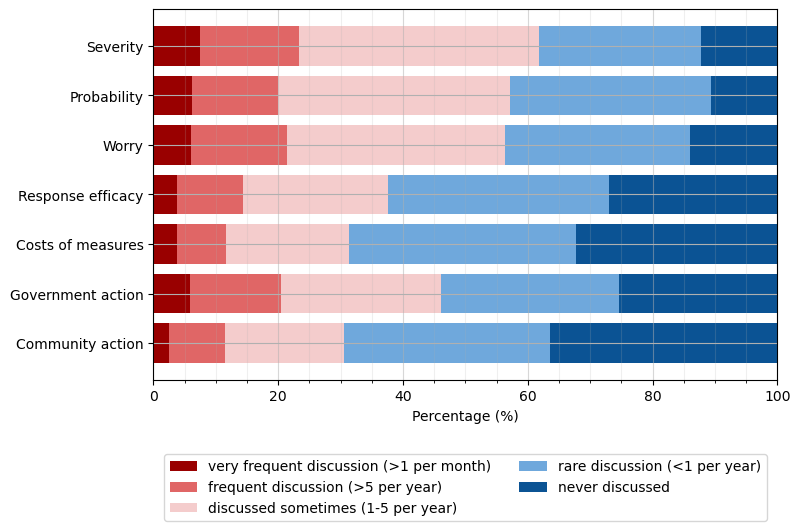

In [25]:
props = data_discussions.drop(columns = ['ID', 'country']).apply(calculate_proportions).T

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(8, 8))

# Colors for each value (1-5)
colors = ['#990000','#e06666','#f4cccc','#6fa8dc','#0b5394']

# Reorder the DataFrame according to specified order
column_order = ['Severity', 'Probability', 'Worry', 'Response_efficacy', 'Costs_of_measures', 'Government_action', 'Community_action']
column_order.reverse()
props_ordered = props.loc[column_order]

legend_labels = {
    1: 'very frequent discussion (>1 per month)',
    2: 'frequent discussion (>5 per year)',
    3: 'discussed sometimes (1-5 per year)',
    4: 'rare discussion (<1 per year)',
    5: 'never discussed' 
}

# Plot each value's proportion
bottom = np.zeros(len(props_ordered))
for value in [1, 2, 3, 4, 5]:
    ax.barh(props_ordered.index, props_ordered[value], left=bottom, color=colors[value-1], label=legend_labels[value])
    bottom += props_ordered[value]

# Add labels and title
ax.set_xlabel('Percentage (%)')
#ax.set_ylabel('Columns')
#ax.set_title('Distribution of Values (1-5) by Column')
ax.legend(bbox_to_anchor=(0.5, -0.4), loc='lower center', ncol = 2, frameon = True)

# Show the plot
plt.tight_layout(rect=[0, 0.2, 1, 1])  # [left, bottom, right, top]

#Grid
major_ticks = np.arange(0, 101, 20)
minor_ticks = np.arange(0, 101, 5)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor = True)
ax.yaxis.grid(None)
ax.xaxis.grid(which='minor', alpha=0.2)
ax.xaxis.grid(which='major', alpha=0.5)
ax.set_xlim(0, 100)
labels = ['Community action', 'Government action', 'Costs of measures', 'Response efficacy', 'Worry', 'Probability', 'Severity']
ax.set_yticklabels(labels)

plt.savefig('../reports/figures/barplot_disc_freq.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

#### Correlations between discussion frequencies

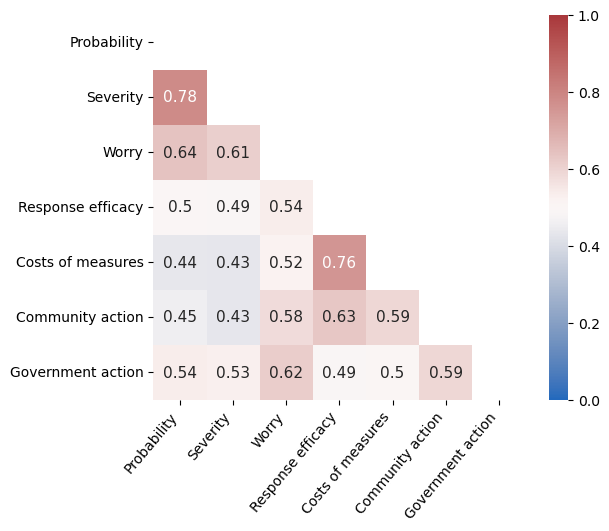

In [26]:
# calculate the correlation matrix on the numeric columns
data_discussions_no_id = data_discussions.drop(columns = ['ID'])
corr = data_discussions_no_id.select_dtypes('number').corr()
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":11},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')
labels = ['Probability', 'Severity', 'Worry', 'Response efficacy', 'Costs of measures','Community action', 'Government action']
ax.set_xticklabels(labels, rotation=50, ha="right")
ax.set_yticklabels(labels)

plt.savefig('../reports/figures/Corr_disc_topic_all.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

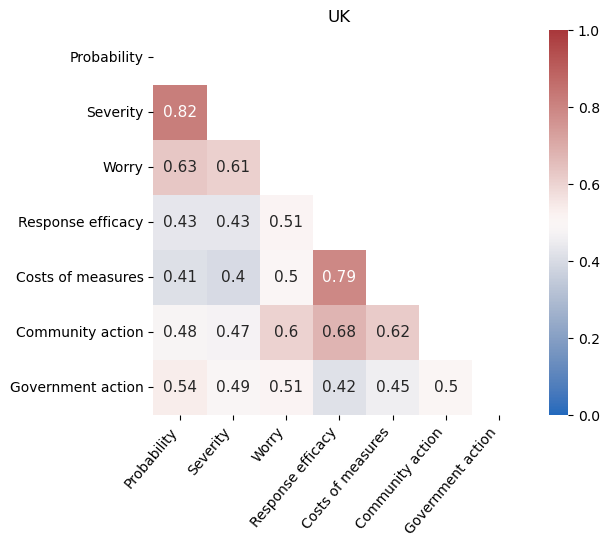

In [27]:
# calculate the correlation matrix on the numeric columns
corr = data_discussions_no_id.loc[data_discussions_no_id['country'] == 'UK'].select_dtypes('number').corr()

# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
plt.title("UK")
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":11},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')
labels = ['Probability', 'Severity', 'Worry', 'Response efficacy', 'Costs of measures','Community action', 'Government action']
ax.set_xticklabels(labels, rotation=50, ha="right")
ax.set_yticklabels(labels)
plt.savefig('../reports/figures/Corr_disc_topic_UK.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

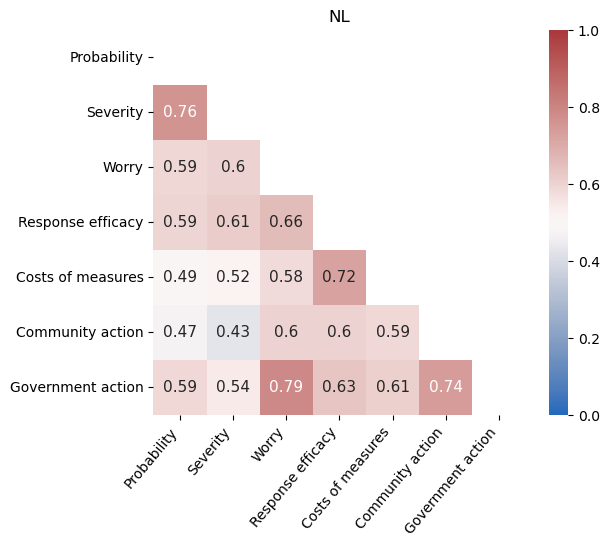

In [28]:
# calculate the correlation matrix on the numeric columns
corr = data_discussions_no_id.loc[data_discussions_no_id['country'] == 'NL'].select_dtypes('number').corr()

# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
plt.title("NL")
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":11},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')
labels = ['Probability', 'Severity', 'Worry', 'Response efficacy', 'Costs of measures','Community action', 'Government action']
ax.set_xticklabels(labels, rotation=50, ha="right")
ax.set_yticklabels(labels)
plt.savefig('../reports/figures/Corr_disc_topic_NL.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

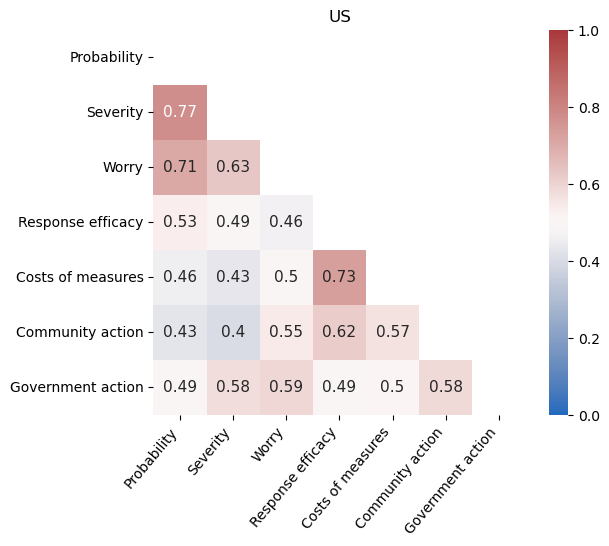

In [17]:
# calculate the correlation matrix on the numeric columns
corr = data_discussions_no_id.loc[data_discussions_no_id['country'] == 'US'].select_dtypes('number').corr()

# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
plt.title("US")
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":11},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')
labels = ['Probability', 'Severity', 'Worry', 'Response efficacy', 'Costs of measures','Community action', 'Government action']
ax.set_xticklabels(labels, rotation=50, ha="right")
ax.set_yticklabels(labels)
plt.savefig('figures/Corr_disc_topic_US.png', dpi = 1000, bbox_inches = 'tight', transparent=True)
plt.show()

## RQ2: Intensity and relation to risk perception and sociodemographics
Does the intensity of social interactions on this topic correspond to differences in individual risk perception and socio-demographic characteristics?

#### Barplots Communicators vs Non-Communicators
Splitting dataframe into communicators and non-communicators along the NG responses

In [29]:
data_used_98_removed_comm_noncomm = data_respondents[(data_respondents.R02_perc_prob != 95) &
                                 (data_respondents.R02_perc_prob != 98) & 
                                 (data_respondents.R02_perc_prob != 97) & 
                                 (data_respondents.R05_worry != 98) &
                                 (data_respondents.Q53_income_q != 99) &
                                 (data_respondents.Q0_education_grouped != 98)
                                ]
data_used_98_removed_comm_noncomm['Fraction_Male'] = 1 * (data_used_98_removed_comm_noncomm['Q0_gender_all'] == 1)
# scaling worry and percevived prob to 0-1
scaler = MinMaxScaler()
data_used_98_removed_comm_noncomm['Perc_Probability'] = scaler.fit_transform(data_used_98_removed_comm_noncomm[['R02_perc_prob']])
data_used_98_removed_comm_noncomm['Worry'] = scaler.fit_transform(data_used_98_removed_comm_noncomm[['R05_worry']])
data_used_98_removed_comm_noncomm['Income'] = scaler.fit_transform(data_used_98_removed_comm_noncomm[['Q53_income_q']])
data_used_98_removed_comm_noncomm['Education'] = scaler.fit_transform(data_used_98_removed_comm_noncomm[['Q0_education_grouped']])
data_used_98_removed_comm_noncomm['Age'] = scaler.fit_transform(data_used_98_removed_comm_noncomm[['Q0_age_grouped']])

data_used_98_removed_comm_noncomm = data_used_98_removed_comm_noncomm.rename(columns={"Flood_exp_overall": "Fraction_Flood_Exp"})

data_comm = data_used_98_removed_comm_noncomm[data_used_98_removed_comm_noncomm.nr_ng_names > 0]
data_non_comm = data_used_98_removed_comm_noncomm[data_used_98_removed_comm_noncomm.nr_ng_names == 0]

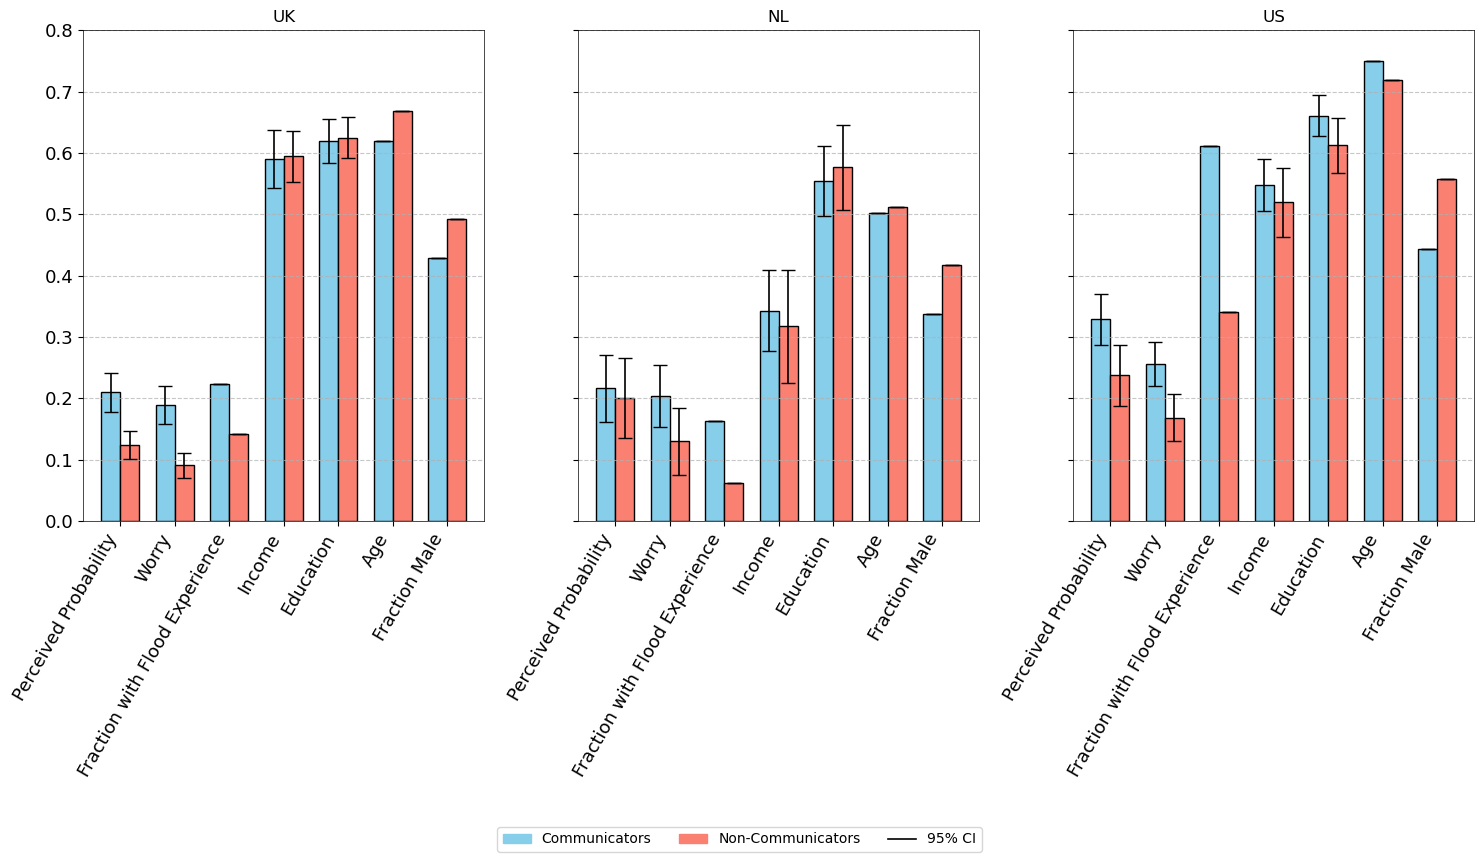

In [30]:
# Define groups and variables
country_groups = ['UK', 'NL', 'US']
variables = ['Perc_Probability', 'Worry', 'Fraction_Flood_Exp',
             'Income', 'Education', 'Age', 'Fraction_Male']

# Normalize function to scale values between 0 and 1
# def normalize(series):
#    return (series - series.min()) / (series.max() - series.min())

# Prepare normalized means and confidence intervals for each group and variable
data = {}
z = 1.96  # Z-score for 95% confidence interval
for group in country_groups:
    data[group] = {'subgroup1': {}, 'subgroup2': {}}
    for variable in variables:
        # Select pre-normalized values directly from the DataFrames
        norm_df1 = data_comm[data_comm['country'] == group][variable]
        norm_df2 = data_non_comm[data_non_comm['country'] == group][variable]

        # Calculate mean and standard deviation
        mean1 = norm_df1.mean()
        std1 = norm_df1.std()
        ci1 = z * (std1 / np.sqrt(len(norm_df1)))  # 95% confidence interval for subgroup 1

        mean2 = norm_df2.mean()
        std2 = norm_df2.std()
        ci2 = z * (std2 / np.sqrt(len(norm_df2)))  # 95% confidence interval for subgroup 2
        

        # Store the results
        data[group]['subgroup1'][variable] = (mean1, ci1)
        data[group]['subgroup2'][variable] = (mean2, ci2)

# Plotting
fig, axes = plt.subplots(1, len(country_groups), figsize=(15, 8), sharey=True)

bar_width = 0.35  # Width of the bars

# Custom legend handles
bar_handle_1 = Patch(color='skyblue', label='Communicators')
bar_handle_2 = Patch(color='salmon', label='Non-Communicators')
error_bar_handle = mlines.Line2D([0], [0], color='black', lw=1.2, label='95% CI')

# Toggle configuration: Specify variables for which CI should be displayed
show_ci = {'Perc_Probability': True, 'Worry': True, 'Fraction_Flood_Exp': False,
             'Income': True, 'Education': True, 'Age': False, 'Fraction_Male': False }

for i, group in enumerate(country_groups):
    ax = axes[i]
    x = np.arange(len(variables)) 
    
    # Get means and CIs for both subgroups for this group
    means1 = [data[group]['subgroup1'][var][0] for var in variables]
    cis1 = [data[group]['subgroup1'][var][1] if show_ci[var] else 0 for var in variables]
    means2 = [data[group]['subgroup2'][var][0] for var in variables]
    cis2 = [data[group]['subgroup2'][var][1] if show_ci[var] else 0 for var in variables]
    
    # Plot subgroup 1 bars
    bars1 = ax.bar(x - bar_width/2, means1, width=bar_width, color='skyblue', 
                   edgecolor = 'black', linewidth = 1, 
                   yerr=cis1, error_kw = {'elinewidth': 1.2},
                   capsize=5)
    
    # Plot subgroup 2 bars
    bars2 = ax.bar(x + bar_width/2, means2, width=bar_width, color='salmon', 
                   edgecolor = 'black', linewidth = 1,
                   yerr=cis2, error_kw = {'elinewidth': 1.2},
                   capsize=5)
    
    # Set x-ticks to be at the center of the bars
    ax.set_xticks(x)
    ax.set_xticklabels(['Perceived Probability', 'Worry', 'Fraction with Flood Experience',
             'Income', 'Education', 'Age', 'Fraction Male'], rotation=60, ha="right")
    ax.tick_params(axis='both', which='major', labelsize=13)
    # Set plot titles and labels
    ax.set_title(f'{group}')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(0, 0.8)
    # Add grid
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Add the legend for one subplot
    #if i == 1:
        
        
    # Add a border around each subplot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        
fig.legend(handles=[bar_handle_1, bar_handle_2, error_bar_handle], loc='outside lower center',  bbox_to_anchor=(0.5, -0.08), ncol=3)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('../reports/figures/Bar-plots-non-comm-comm.png', bbox_inches = 'tight', dpi = 1000, transparent=True)
plt.show()

This is with all the variables normalised between 0 and 1 (MinMax Scaler). All variables are considered (quasi-) continuous. E.g. education goes from 1-4 with 4 being highest education and 1 lowest, age from 1-6 from young to old, income from 1-5 from low income to higherst income quintile, etc. Only the gender was not considered continuous, so we used the fraction of male respondents to be shown here. The rest are not all female (some non-binary, etc), but these are only very few. 

#### Interaction Levels
Using the data on the interaction variables and clustering over them to determine interaction levels.

In [31]:
data_interaction_level = data_respondents[['Q27_fl_convo_people', 'Q25_fl_convo_times', 'nr_ng_names']]
# splitting data into those who communicate and those who don't. Use data on theose who communicate for clustering
data_interaction_level_comm = data_interaction_level[data_interaction_level['nr_ng_names'] > 0]
data_interaction_level_non_comm = data_interaction_level[data_interaction_level['nr_ng_names'] == 0]

In [32]:
data_interaction_level_comm.mean()

Q27_fl_convo_people    2.612667
Q25_fl_convo_times     3.447016
nr_ng_names            2.548112
dtype: float64

In [33]:
data_interaction_level_comm.var()

Q27_fl_convo_people     55.252230
Q25_fl_convo_times     179.801153
nr_ng_names              0.594329
dtype: float64

In [34]:
# scaling the data
scaler = MinMaxScaler() 
data_interaction_level_scaled = scaler.fit_transform(data_interaction_level_comm)
data_interaction_level_scaled

array([[0.01 , 0.   , 1.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 0.   ],
       ...,
       [0.01 , 0.005, 0.   ],
       [0.05 , 0.   , 0.5  ],
       [0.03 , 0.015, 1.   ]])

Using k-median clustering

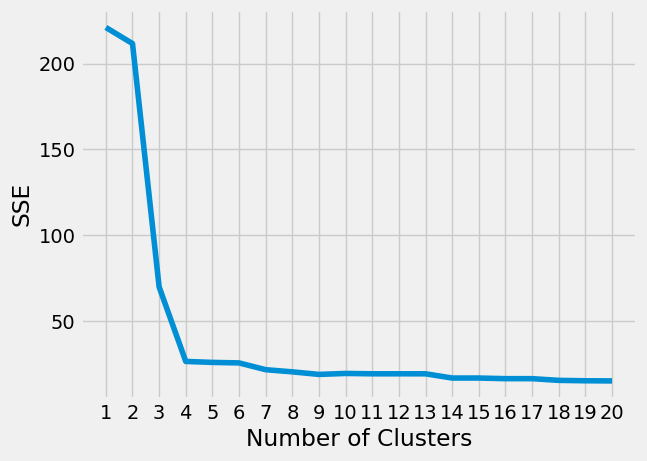

In [35]:
# SSE over clusters plot to determine nr of clusters
kmeans_kwargs = {"init": "random","random_state": 0, 'metric': 'manhattan'}
sse = []
for k in range(1, 21):
    kmedoids = KMedoids(n_clusters=k, **kmeans_kwargs)
    kmedoids.fit(data_interaction_level_scaled)
    sse.append(kmedoids.inertia_)
    
plt.style.use("fivethirtyeight")
plt.plot(range(1, 21), sse)
plt.xticks(range(1, 21))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [36]:
kl = KneeLocator(range(1, 21), sse, curve="convex", direction="decreasing")
kl.elbow

4

Text(0.5, 1.0, 'K-Median Clustering Results with K=4')

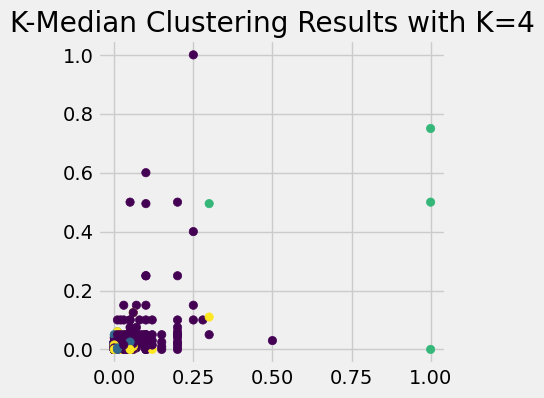

In [37]:
kmed4 = KMedoids(n_clusters=4,
                random_state=0,
                metric = 'manhattan',
                init='k-medoids++')
kmed4.fit(data_interaction_level_scaled)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(data_interaction_level_scaled[:,0], data_interaction_level_scaled[:,1], c=kmed4.labels_)
ax.set_title("K-Median Clustering Results with K=4")

In [38]:
# size of different clusters
unique, counts = np.unique(kmed4.labels_, return_counts=True) 
dict(zip(unique, counts))

{0: 588, 1: 142, 2: 4, 3: 87}

Text(0.5, 1.0, 'K-Median Clustering Results with K=3')

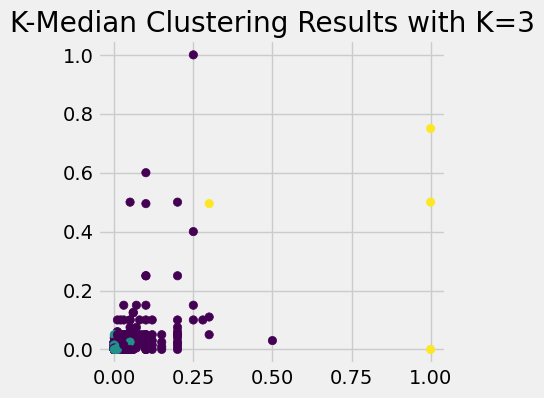

In [39]:
kmed3 = KMedoids(n_clusters=3,
                random_state=0,
                metric = 'manhattan',
                init='k-medoids++')
kmed3.fit(data_interaction_level_scaled)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(data_interaction_level_scaled[:,0], data_interaction_level_scaled[:,1], c=kmed3.labels_)
ax.set_title("K-Median Clustering Results with K=3")

In [40]:
# size of different clusters
unique, counts = np.unique(kmed3.labels_, return_counts=True) 
dict(zip(unique, counts))

{0: 650, 1: 167, 2: 4}

##### Davies-Boulding Index
To determine what number of clusters to use (Lower score is better)

In [41]:
db_score = davies_bouldin_score(data_interaction_level_comm, kmed3.labels_) # data_interaction_level_scaled
print(f"Davies-Bouldin Index 3 clusters: {db_score:.3f}")
db_score = davies_bouldin_score(data_interaction_level_comm, kmed4.labels_)
print(f"Davies-Bouldin Index 4 clusters: {db_score:.3f}")

Davies-Bouldin Index 3 clusters: 1.404
Davies-Bouldin Index 4 clusters: 2.960


#### Adding the clusters to the rest of the data

In [42]:
data_interaction_level_comm['3Clusters_comm'] = kmed3.labels_
data_interaction_level_comm['4Clusters_comm'] = kmed4.labels_
data_interaction_level_comm.head()

,Q27_fl_convo_people,Q25_fl_convo_times,nr_ng_names,3Clusters_comm,4Clusters_comm
0,1.0,0,3.0,0,0
4,0.0,0,3.0,0,0
5,0.0,0,1.0,1,1
6,1.0,1,3.0,0,0
8,0.0,0,2.0,1,3


In [43]:
df_interaction_3cl = pd.merge(data_interaction_level_comm, data_respondents, left_index=True, right_index=True)
df_interaction_3cl.shape

(821, 30)

In [44]:
data_interaction_level_comm.groupby(['3Clusters_comm']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q27_fl_convo_people                                       \
                              mean        std   min    max median    q1   
3Clusters_comm                                                            
0                         2.687692   4.836559   0.0   50.0    1.0   0.0   
1                         0.407186   0.800269   0.0    5.0    0.0   0.0   
2                        82.500000  35.000000  30.0  100.0  100.0  82.5   

                      Q25_fl_convo_times                                    \
                   q3               mean        std min  max median     q1   
3Clusters_comm                                                               
0                 3.0           3.601538  12.770814   0  200    1.0   0.00   
1                 1.0           0.838323   1.726189   0   12    0.0   0.00   
2               100.0          87.250000  62.851014   0  150   99.5  74.25   

                      nr_ng_names                                       \
                   q3        mean       std  min  max median   q1   q3   
3Clusters_comm                                                           
0                 3.0    2.904615  0.293972  2.0  3.0    3.0  3.0  3.0   
1                 1.0    1.149701  0.357851  1.0  2.0    1.0  1.0  1.0   
2               112.5    3.000000  0.000000  3.0  3.0    3.0  3.0  3.0   

               4Clusters_comm                                     
                         mean       std min max median   q1   q3  
3Clusters_comm                                                    
0                    0.286154  0.881915   0   3    0.0  0.0  0.0  
1                    1.299401  0.715701   1   3    1.0  1.0  1.0  
2                    2.000000  0.000000   2   2    2.0  2.0  2.0

K-Median 3 clusters:
- cluster 0: 2-3 names given, talking to 2-3 people on average, had around 3-4 conversations --> high communicators --> combination of cluster 0 and 3 of 4 clusters
- cluster 1: 1-2 name given, talking to hardly anyone --> below 1 conversation on average, less than 1 person talked to --> low communicators
- cluster 2: 3 names given, many many flood convos and people --> super high communicators --> only 4 people --> outliers

In [45]:
data_interaction_level_comm.groupby(['4Clusters_comm']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q27_fl_convo_people                                       \
                              mean        std   min    max median    q1   
4Clusters_comm                                                            
0                         2.646259   4.923680   0.0   50.0    1.0   0.0   
1                         0.478873   0.848180   0.0    5.0    0.0   0.0   
2                        82.500000  35.000000  30.0  100.0  100.0  82.5   
3                         2.195402   3.592107   0.0   30.0    2.0   0.0   

                      Q25_fl_convo_times                                    \
                   q3               mean        std min  max median     q1   
4Clusters_comm                                                               
0                 3.0           3.700680  13.340216   0  200    0.0   0.00   
1                 1.0           0.901408   1.826945   0   12    0.0   0.00   
2               100.0          87.250000  62.851014   0  150   99.5  74.25   
3                 2.0           2.034483   4.076159   0   25    1.0   0.00   

                      nr_ng_names                                  \
                   q3        mean  std  min  max median   q1   q3   
4Clusters_comm                                                      
0                 3.0         3.0  0.0  3.0  3.0    3.0  3.0  3.0   
1                 1.0         1.0  0.0  1.0  1.0    1.0  1.0  1.0   
2               112.5         3.0  0.0  3.0  3.0    3.0  3.0  3.0   
3                 2.0         2.0  0.0  2.0  2.0    2.0  2.0  2.0   

               3Clusters_comm                                     
                         mean       std min max median   q1   q3  
4Clusters_comm                                                    
0                    0.000000  0.000000   0   0    0.0  0.0  0.0  
1                    1.000000  0.000000   1   1    1.0  1.0  1.0  
2                    2.000000  0.000000   2   2    2.0  2.0  2.0  
3                    0.287356  0.455153   0   1    0.0  0.0  1.0

K-Median 4 clusters:
- cluster 0: 3 names given, talking to 2-3 people on average, had around 3 conversations --> high communicators
- cluster 1: 1 name given, talking to hardly anyone --> below 1 conversation on average, less than 1 person talked to --> low communicators
- cluster 2: 3 names given, many many flood convos and people --> super high communicators --> only 4 people --> outliers
- cluster 3: 2 names given, talking to 2 people on average, had around 3 conversations

##### Getting descriptives for the interaction levels and the non-Communicators

In [46]:
df_interaction_3cl['Fraction_Male'] = 1 * (df_interaction_3cl['Q0_gender_all'] == 1)

df_interaction_3cl_idk_removed = df_interaction_3cl[(df_interaction_3cl.R02_perc_prob != 95) &
                                                (df_interaction_3cl.R02_perc_prob != 98) & 
                                                (df_interaction_3cl.R02_perc_prob != 97) & 
                                                (df_interaction_3cl.R05_worry != 98) &
                                                (df_interaction_3cl.Q53_income_q != 99) &
                                                (df_interaction_3cl.Q0_education_grouped != 98) &
                                                (df_interaction_3cl.Q1_home != 97) &
                                                (df_interaction_3cl.Q1_home != 98)]
                                               
df_interaction_3cl_group = df_interaction_3cl_idk_removed.drop(columns = ['country']).groupby('3Clusters_comm').agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])
df_interaction_3cl_group = df_interaction_3cl_group.drop(columns = ['ID', 'name_generator', 'Q27_fl_convo_people_x', 'Q25_fl_convo_times_x', 'nr_ng_names_x'])
df_interaction_3cl_group

4Clusters_comm                                     \
                         mean       std min max median   q1   q3   
3Clusters_comm                                                     
0                    0.316176  0.922305   0   3    0.0  0.0  0.0   
1                    1.333333  0.749037   1   3    1.0  1.0  1.0   
2                    2.000000  0.000000   2   2    2.0  2.0  2.0   

               nr_ng_names_y                                       \
                        mean       std  min  max median   q1   q3   
3Clusters_comm                                                      
0                   2.894608  0.307435  2.0  3.0    3.0  3.0  3.0   
1                   1.166667  0.374518  1.0  2.0    1.0  1.0  1.0   
2                   3.000000  0.000000  3.0  3.0    3.0  3.0  3.0   

               Q27_fl_convo_people_y                                       \
                                mean        std   min    max median    q1   
3Clusters_comm                                                              
0                           3.093137   5.172328   0.0   50.0    2.0   0.0   
1                           0.470588   0.908768   0.0    5.0    0.0   0.0   
2                          82.500000  35.000000  30.0  100.0  100.0  82.5   

                      Q25_fl_convo_times_y                                    \
                   q3                 mean        std min  max median     q1   
3Clusters_comm                                                                 
0                 4.0             4.291667  14.395288   0  200    1.0   0.00   
1                 1.0             0.990196   1.709004   0   10    0.0   0.00   
2               100.0            87.250000  62.851014   0  150   99.5  74.25   

                      R02_perc_prob                                      \
                   q3          mean       std min max median   q1    q3   
3Clusters_comm                                                            
0                 3.0      3.169118  2.346690   1   9    2.0  1.0  5.00   
1                 1.0      2.558824  1.972953   1   8    2.0  1.0  4.00   
2               112.5      5.250000  3.774917   2   9    5.0  2.0  8.25   

               R03_perc_damage_all                                           \
                              mean        std  min   max median   q1     q3   
3Clusters_comm                                                                
0                        22.458333  39.105078  1.0  98.0    3.0  1.0   5.00   
1                        36.911765  46.327953  1.0  98.0    3.0  1.0  98.00   
2                         2.250000   1.892969  1.0   5.0    1.5  1.0   2.75   

               R05_worry                                       \
                    mean       std min max median    q1    q3   
3Clusters_comm                                                  
0               1.921569  1.053239   1   5    2.0  1.00  2.00   
1               1.656863  0.928057   1   5    1.0  1.00  2.00   
2               2.000000  0.816497   1   3    2.0  1.75  2.25   

               Flood_exp_overall                                        \
                            mean       std  min  max median    q1   q3   
3Clusters_comm                                                           
0                       0.394608  0.489366  0.0  1.0    0.0  0.00  1.0   
1                       0.303922  0.462221  0.0  1.0    0.0  0.00  1.0   
2                       0.750000  0.500000  0.0  1.0    1.0  0.75  1.0   

               perc_prob_dam_idk                                     \
                            mean       std min max median   q1   q3   
3Clusters_comm                                                        
0                       0.210784  0.408366   0   1    0.0  0.0  0.0   
1                       0.362745  0.483166   0   1    0.0  0.0  1.0   
2                       0.000000  0.000000   0   0    0.0  0.0  0.0   

               perc_prob_idk                              

In [47]:
data_used_non_comm = data_respondents[data_respondents['nr_ng_names'] == 0]
data_used_non_comm['Fraction_Male'] = 1 * (data_used_non_comm['Q0_gender_all'] == 1)
data_used_non_comm_idk_removed = data_used_non_comm[(data_used_non_comm.R02_perc_prob != 95) &
                                                (data_used_non_comm.R02_perc_prob != 98) & 
                                                (data_used_non_comm.R02_perc_prob != 97) & 
                                                (data_used_non_comm.R05_worry != 98) &
                                                (data_used_non_comm.Q53_income_q != 99) &
                                                (data_used_non_comm.Q0_education_grouped != 98) &
                                                (data_used_non_comm.Q1_home != 97) &
                                                (data_used_non_comm.Q1_home != 98) ]
                                               # (data_used_non_comm.Q0_gender_all != 99)]
data_used_non_comm.describe() # to get avg nr ng names, flood convo people, flood convo times

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov,Fraction_Male
count,786.000000,786.0,786.0,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,786.000000
mean,506.904580,0.0,0.0,0.376590,0.622137,13.777354,39.253181,3.254453,0.166667,0.428753,0.118321,334.623410,34.586514,4.132316,11.541985,4.227735,7.708651,3.594203,3.347826,3.550725,3.739130,3.942029,3.971014,3.739130,0.492366
std,487.628288,0.0,0.0,2.521381,4.276253,31.099758,46.819434,12.794760,0.372915,0.495213,0.323193,748.759304,45.071304,11.221013,28.718425,1.589871,23.816878,1.088967,1.135342,1.091898,1.093459,1.136093,1.150077,1.244425,0.500260
min,0.000000,0.0,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,182.250000,0.0,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.000000
50%,356.000000,0.0,0.0,0.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,2.000000,5.000000,2.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000
75%,642.750000,0.0,0.0,0.000000,0.000000,5.000000,98.000000,2.000000,0.000000,1.000000,0.000000,0.000000,99.000000,3.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,1.000000
max,2250.000000,0.0,0.0,55.000000,100.000000,98.000000,98.000000,98.000000,1.000000,1.000000,1.000000,2023.000000,99.000000,98.000000,98.000000,6.000000,99.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


In [48]:
data_used_non_comm_idk_removed.describe() # for averages of rest

,ID,name_generator,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times,R02_perc_prob,R03_perc_damage_all,R05_worry,Flood_exp_overall,perc_prob_dam_idk,perc_prob_idk,Last_flood_exp_year,Q53_income_q,Q0_education_grouped,Q1_home,Q0_age_grouped,Q0_gender_all,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_community,Q28_convo_gov,Fraction_Male
count,445.000000,445.0,445.0,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.0,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,445.000000
mean,576.671910,0.0,0.0,0.483146,0.602247,2.285393,22.880899,1.462921,0.197753,0.217978,0.0,397.175281,3.235955,2.853933,2.114607,4.316854,4.797753,3.568182,3.250000,3.545455,3.659091,3.954545,3.954545,3.636364,0.507865
std,510.449114,0.0,0.0,3.188918,2.991202,1.895202,39.717263,0.780734,0.398753,0.413337,0.0,800.919798,1.439645,0.848297,0.842501,1.538049,17.624704,1.108062,1.123222,1.109254,1.160256,1.219122,1.199894,1.240610,0.500501
min,0.000000,0.0,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,230.000000,0.0,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,2.000000,2.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.000000
50%,437.000000,0.0,0.0,0.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.0,0.000000,3.000000,3.000000,2.000000,5.000000,1.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
75%,698.000000,0.0,0.0,0.000000,0.000000,3.000000,4.000000,2.000000,0.000000,0.000000,0.0,0.000000,5.000000,4.000000,3.000000,6.000000,2.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,1.000000
max,2250.000000,0.0,0.0,55.000000,50.000000,9.000000,98.000000,5.000000,1.000000,1.000000,0.0,2023.000000,5.000000,4.000000,4.000000,6.000000,99.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


### Significant differences between the groups
Checking which variables differ significantly between the groups.

In [49]:
Non_comm_interaction_data = data_used_non_comm[['nr_ng_names', 'Q27_fl_convo_people', 'Q25_fl_convo_times']]
Non_comm_socio_dem_RP_data = data_used_non_comm_idk_removed[['R02_perc_prob', 'R05_worry', 'Flood_exp_overall', 'Q53_income_q', 'Q0_education_grouped', 'Q0_age_grouped', 'Fraction_Male']]
# leaving out proportion perc prob idk, fraction flood experience, fraction male as these are not continuous data

In [50]:
Low_comm_interaction_data = df_interaction_3cl.loc[df_interaction_3cl['3Clusters_comm'] == 1][['nr_ng_names_x', 'Q27_fl_convo_people_x', 'Q25_fl_convo_times_x']]
Low_comm_socio_dem_RP_data = df_interaction_3cl_idk_removed.loc[df_interaction_3cl_idk_removed['3Clusters_comm'] == 1][['R02_perc_prob', 'R05_worry','Flood_exp_overall', 'Q53_income_q', 'Q0_education_grouped', 'Q0_age_grouped', 'Fraction_Male']]

Comm_interaction_data = df_interaction_3cl.loc[df_interaction_3cl['3Clusters_comm'] == 0][['nr_ng_names_x', 'Q27_fl_convo_people_x', 'Q25_fl_convo_times_x']]
Comm_socio_dem_RP_data = df_interaction_3cl_idk_removed.loc[df_interaction_3cl_idk_removed['3Clusters_comm'] == 0][['R02_perc_prob', 'R05_worry','Flood_exp_overall', 'Q53_income_q', 'Q0_education_grouped', 'Q0_age_grouped', 'Fraction_Male']]

# leaving out cluster 2 as these are the outliers
Low_comm_interaction_data = Low_comm_interaction_data.rename(columns={'nr_ng_names_x': 'nr_ng_names', 
                                          'Q27_fl_convo_people_x': 'Q27_fl_convo_people',
                                          'Q25_fl_convo_times_x': 'Q25_fl_convo_times'})
Comm_interaction_data = Comm_interaction_data.rename(columns={'nr_ng_names_x': 'nr_ng_names', 
                                          'Q27_fl_convo_people_x': 'Q27_fl_convo_people',
                                          'Q25_fl_convo_times_x': 'Q25_fl_convo_times'})

In [51]:
# Add group labels and combine
Non_comm_interaction_data['group'] = 'NonComm'
Low_comm_interaction_data['group'] = 'LowComm'
Comm_interaction_data['group'] = 'Comm'
combined_df_interaction_data = pd.concat([Non_comm_interaction_data, Low_comm_interaction_data, Comm_interaction_data], ignore_index=True)

In [52]:
variables = ['nr_ng_names', 'Q27_fl_convo_people', 'Q25_fl_convo_times']

# Initialize a dictionary to store results
results = {}

for var in variables:
    # One-way ANOVA
    groups = [combined_df_interaction_data[var][combined_df_interaction_data['group'] == g] for g in ['NonComm', 'LowComm', 'Comm']]
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Store ANOVA results
    results[var] = {
        'anova_p': p_value,
        'significant': p_value < 0.05,
        'posthoc': None
    }
    
    # If ANOVA is significant, run Tukey HSD post-hoc test
    if results[var]['significant']:
        tukey = mc.MultiComparison(combined_df_interaction_data[var], combined_df_interaction_data['group'])
        tukey_results = tukey.tukeyhsd()
        results[var]['posthoc'] = tukey_results

# Print summary of significant variables
print("===== Significant Variables =====")
for var, res in results.items():
    if res['significant']:
        print(f"\nVariable: {var}")
        print(f"  ANOVA p-value: {res['anova_p']:.4f}")
        print("  Post-hoc Tukey HSD results:")
        print(res['posthoc'])

# Print non-significant variables
print("\n===== Non-Significant Variables =====")
for var, res in results.items():
    if not res['significant']:
        print(f"{var}: ANOVA p-value = {res['anova_p']:.4f}")

===== Significant Variables =====

Variable: nr_ng_names
  ANOVA p-value: 0.0000
  Post-hoc Tukey HSD results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower   upper  reject
-----------------------------------------------------
   Comm LowComm  -1.7549   0.0 -1.7997 -1.7102   True
   Comm NonComm  -2.9046   0.0  -2.932 -2.8773   True
LowComm NonComm  -1.1497   0.0 -1.1936 -1.1058   True
-----------------------------------------------------

Variable: Q27_fl_convo_people
  ANOVA p-value: 0.0000
  Post-hoc Tukey HSD results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
   Comm LowComm  -2.2805    0.0  -3.005  -1.556   True
   Comm NonComm  -2.3111    0.0 -2.7539 -1.8683   True
LowComm NonComm  -0.0306 0.9944 -0.7422   0.681  False
------------------------------------------------------

Variable: Q25_fl_convo_times
  ANOVA p-v

In [53]:
# Add group labels and combine
Non_comm_socio_dem_RP_data['group'] = 'NonComm'
Low_comm_socio_dem_RP_data['group'] = 'LowComm'
Comm_socio_dem_RP_data['group'] = 'Comm'
combined_df_socio_dem_RP_data = pd.concat([Non_comm_socio_dem_RP_data, Low_comm_socio_dem_RP_data, Comm_socio_dem_RP_data], ignore_index=True)

In [54]:
variables = ['R02_perc_prob', 'R05_worry', 'Flood_exp_overall','Q53_income_q', 'Q0_education_grouped', 'Q0_age_grouped', 'Fraction_Male']

# Initialize a dictionary to store results
results = {}

for var in variables:
    # One-way ANOVA
    groups = [combined_df_socio_dem_RP_data[var][combined_df_socio_dem_RP_data['group'] == g] for g in ['NonComm', 'LowComm', 'Comm']]
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Store ANOVA results
    results[var] = {
        'anova_p': p_value,
        'significant': p_value < 0.05,
        'posthoc': None
    }
    
    # If ANOVA is significant, run Tukey HSD post-hoc test
    if results[var]['significant']:
        tukey = mc.MultiComparison(combined_df_socio_dem_RP_data[var], combined_df_socio_dem_RP_data['group'])
        tukey_results = tukey.tukeyhsd()
        results[var]['posthoc'] = tukey_results

# Print summary of significant variables
print("===== Significant Variables =====")
for var, res in results.items():
    if res['significant']:
        print(f"\nVariable: {var}")
        print(f"  ANOVA p-value: {res['anova_p']:.4f}")
        print("  Post-hoc Tukey HSD results:")
        print(res['posthoc'])

# Print non-significant variables
print("\n===== Non-Significant Variables =====")
for var, res in results.items():
    if not res['significant']:
        print(f"{var}: ANOVA p-value = {res['anova_p']:.4f}")

===== Significant Variables =====

Variable: R02_perc_prob
  ANOVA p-value: 0.0000
  Post-hoc Tukey HSD results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
   Comm LowComm  -0.6103 0.0245  -1.158 -0.0626   True
   Comm NonComm  -0.8837    0.0 -1.2228 -0.5446   True
LowComm NonComm  -0.2734 0.4644 -0.8166  0.2697  False
------------------------------------------------------

Variable: R05_worry
  ANOVA p-value: 0.0000
  Post-hoc Tukey HSD results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
   Comm LowComm  -0.2647 0.0261 -0.5043 -0.0251   True
   Comm NonComm  -0.4586    0.0  -0.607 -0.3103   True
LowComm NonComm  -0.1939 0.1346 -0.4315  0.0436  False
------------------------------------------------------

Variable: Flood_exp_overall
  ANOVA p-val

#### Correlations between risk perception and interactions

In [55]:
data_int_risk = data_respondents[['R02_perc_prob', 'R05_worry', 'Flood_exp_overall', 'nr_ng_names', 'Q27_fl_convo_people', 'Q25_fl_convo_times']]
data_int_risk_no_idk = data_int_risk[(data_int_risk.R02_perc_prob != 95) &
                                 (data_int_risk.R02_perc_prob != 98) & 
                                 (data_int_risk.R02_perc_prob != 97) & 
                                 (data_int_risk.R05_worry != 98)
                                ]
data_int_risk_no_idk.describe()

,R02_perc_prob,R05_worry,Flood_exp_overall,nr_ng_names,Q27_fl_convo_people,Q25_fl_convo_times
count,1417.000000,1417.000000,1417.000000,1417.000000,1417.000000,1417.000000
mean,2.643613,1.642202,0.239944,1.321807,1.606210,2.199012
std,2.082857,0.914261,0.427200,1.393907,5.965074,10.663639
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,4.000000,2.000000,0.000000,3.000000,1.000000,1.000000
max,9.000000,5.000000,1.000000,3.000000,100.000000,200.000000


<Axes: >

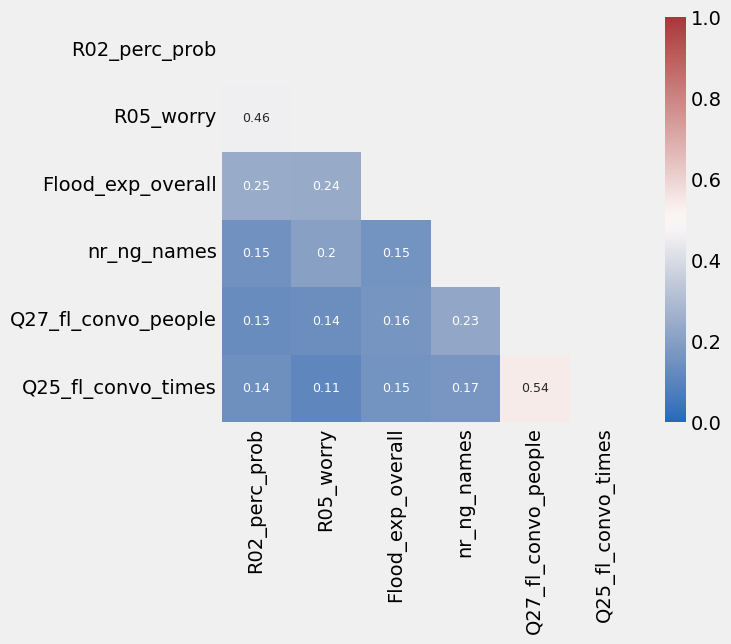

In [56]:
# calculate the correlation matrix on the numeric columns
corr = data_int_risk_no_idk.select_dtypes('number').corr()
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":9},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')

<Axes: >

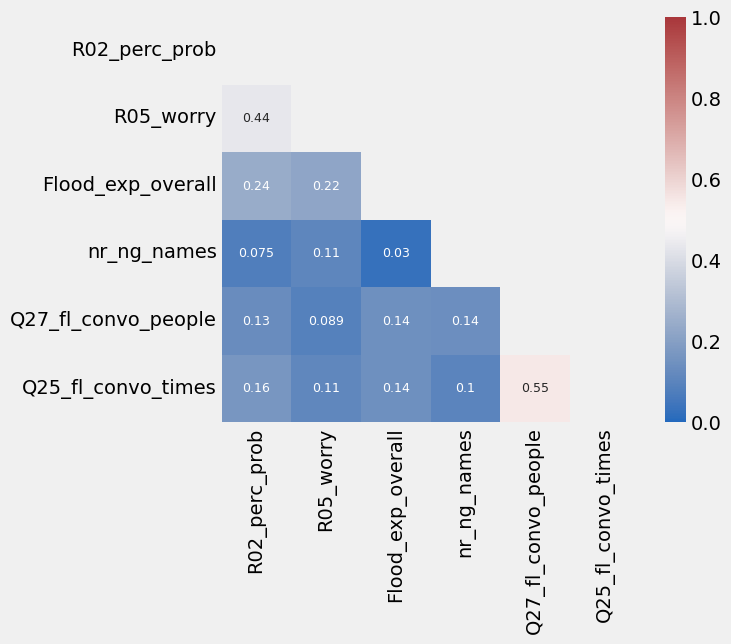

In [57]:
# same as above but with non-interactors removed
# calculate the correlation matrix on the numeric columns
data_int_risk_no_idk_comm = data_int_risk_no_idk[data_int_risk_no_idk.nr_ng_names != 0]
corr = data_int_risk_no_idk_comm.select_dtypes('number').corr()
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)
# plot the heatmap
fig, ax = plt.subplots(figsize=(6,5)) 
ax.grid(False)
sns.heatmap(corr, 
            annot = True, annot_kws={"fontsize":9},
            vmin = 0, vmax = 1, 
            mask=matrix,
            cmap = 'vlag')

In [58]:
# only communicators
# Define the sets
risk_variables = ['R02_perc_prob', 'R05_worry', 'Flood_exp_overall']
interaction_variables = ['nr_ng_names', 'Q27_fl_convo_people', 'Q25_fl_convo_times']

# Create empty DataFrames to store the correlation results and p-values
correlation_results_spearman = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_spearman = pd.DataFrame(index=risk_variables, columns=interaction_variables)

correlation_results_kendall = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_kendall = pd.DataFrame(index=risk_variables, columns=interaction_variables)

correlation_results_pearson = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_pearson = pd.DataFrame(index=risk_variables, columns=interaction_variables)

# Compute pairwise correlations for Spearman
for x in risk_variables:
    for y in interaction_variables:
        corr_spearman, p_value_spearman = spearmanr(data_int_risk_no_idk_comm[x], data_int_risk_no_idk_comm[y])
        correlation_results_spearman.loc[x, y] = corr_spearman
        p_values_spearman.loc[x, y] = p_value_spearman

# Compute pairwise correlations for Kendall's tau
for x in risk_variables:
    for y in interaction_variables:
        corr_kendall, p_value_kendall = kendalltau(data_int_risk_no_idk_comm[x], data_int_risk_no_idk_comm[y])
        correlation_results_kendall.loc[x, y] = corr_kendall
        p_values_kendall.loc[x, y] = p_value_kendall
        
# Compute pairwise correlations for Pearson        
for x in risk_variables:
    for y in interaction_variables:
        corr, p_value = pearsonr(data_int_risk_no_idk_comm[x], data_int_risk_no_idk_comm[y])  # Use spearmanr for Spearman or kendalltau for Kendall’s tau
        correlation_results_pearson.loc[x, y] = corr
        p_values_pearson.loc[x, y] = p_value

# Display results
print('Using only communicator (NG >0) data')
print("Spearman Correlation matrix:")
print(correlation_results_spearman)

print("\nSpearman P-value matrix:")
print(p_values_spearman)

print("\nKendall's tau Correlation matrix:")
print(correlation_results_kendall)

print("\nKendall's tau P-value matrix:")
print(p_values_kendall)

print("Pearson Correlation matrix:")
print(correlation_results_pearson)

print("\nPearson P-value matrix:")
print(p_values_pearson)

Using only communicator (NG >0) data
Spearman Correlation matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob        0.063835            0.239161           0.242208
R05_worry             0.11165            0.267515           0.288557
Flood_exp_overall    0.027563            0.254492           0.292364

Spearman P-value matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob        0.085008                 0.0                0.0
R05_worry            0.002538                 0.0                0.0
Flood_exp_overall    0.457443                 0.0                0.0

Kendall's tau Correlation matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob          0.0551            0.194051           0.198816
R05_worry            0.102172            0.228504           0.246824
Flood_exp_overall    0.026735            0.229203           0.264687

Kendall's tau P-value matrix:
              

In [59]:
# only communicators
# Define the sets
risk_variables = ['R02_perc_prob', 'R05_worry', 'Flood_exp_overall']
interaction_variables = ['nr_ng_names', 'Q27_fl_convo_people', 'Q25_fl_convo_times']

# Create empty DataFrames to store the correlation results and p-values
correlation_results_spearman = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_spearman = pd.DataFrame(index=risk_variables, columns=interaction_variables)

correlation_results_kendall = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_kendall = pd.DataFrame(index=risk_variables, columns=interaction_variables)

correlation_results_pearson = pd.DataFrame(index=risk_variables, columns=interaction_variables)
p_values_pearson = pd.DataFrame(index=risk_variables, columns=interaction_variables)

# Compute pairwise correlations for Spearman
for x in risk_variables:
    for y in interaction_variables:
        corr_spearman, p_value_spearman = spearmanr(data_int_risk_no_idk[x], data_int_risk_no_idk[y])
        correlation_results_spearman.loc[x, y] = corr_spearman
        p_values_spearman.loc[x, y] = p_value_spearman

# Compute pairwise correlations for Kendall's tau
for x in risk_variables:
    for y in interaction_variables:
        corr_kendall, p_value_kendall = kendalltau(data_int_risk_no_idk[x], data_int_risk_no_idk[y])
        correlation_results_kendall.loc[x, y] = corr_kendall
        p_values_kendall.loc[x, y] = p_value_kendall
        
# Compute pairwise correlations for Pearson        
for x in risk_variables:
    for y in interaction_variables:
        corr, p_value = pearsonr(data_int_risk_no_idk[x], data_int_risk_no_idk[y])  # Use spearmanr for Spearman or kendalltau for Kendall’s tau
        correlation_results_pearson.loc[x, y] = corr
        p_values_pearson.loc[x, y] = p_value

# Display results
print('Using all data (comm and non-comm)')
print("Spearman Correlation matrix:")
print(correlation_results_spearman)

print("\nSpearman P-value matrix:")
print(p_values_spearman)

print("\nKendall's tau Correlation matrix:")
print(correlation_results_kendall)

print("\nKendall's tau P-value matrix:")
print(p_values_kendall)


print("Pearson Correlation matrix:")
print(correlation_results_pearson)

print("\nPearson P-value matrix:")
print(p_values_pearson)

Using all data (comm and non-comm)
Spearman Correlation matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob        0.145811             0.23136           0.248606
R05_worry            0.209621            0.295318           0.305582
Flood_exp_overall    0.154476            0.252597            0.28995

Spearman P-value matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob             0.0                 0.0                0.0
R05_worry                 0.0                 0.0                0.0
Flood_exp_overall         0.0                 0.0                0.0

Kendall's tau Correlation matrix:
                  nr_ng_names Q27_fl_convo_people Q25_fl_convo_times
R02_perc_prob        0.125433             0.19677           0.211562
R05_worry            0.190297            0.264767           0.272627
Flood_exp_overall    0.146928             0.23671           0.271168

Kendall's tau P-value matrix:
                

In [60]:
# Overall set correlation
# Extract data as numpy arrays for CCA
risk_data = data_int_risk_no_idk[risk_variables].values
interaction_data = data_int_risk_no_idk[interaction_variables].values

# Perform CCA
cca = CCA(n_components=1)  # Use 1 component for max correlation
risk_c, interacion_c = cca.fit_transform(risk_data, interaction_data)

# Calculate Pearson correlation of the transformed components
overall_corr, overall_p_value = pearsonr(risk_c[:, 0], interacion_c[:, 0])

print("Overall canonical correlation:", overall_corr)
print("Overall p-value:", overall_p_value)

Overall canonical correlation: 0.2866034763387409
Overall p-value: 3.3857752161357675e-28


In [61]:
# Overall set correlation
# Extract data as numpy arrays for CCA
risk_data = data_int_risk_no_idk_comm[risk_variables].values
interaction_data = data_int_risk_no_idk_comm[interaction_variables].values

# Perform CCA
cca = CCA(n_components=1)  # Use 1 component for max correlation
risk_c, interacion_c = cca.fit_transform(risk_data, interaction_data)

# Calculate Pearson correlation of the transformed components
overall_corr, overall_p_value = pearsonr(risk_c[:, 0], interacion_c[:, 0])

print('only comm data')
print("Overall canonical correlation:", overall_corr)
print("Overall p-value:", overall_p_value)

only comm data
Overall canonical correlation: 0.21898612026673306
Overall p-value: 2.2987815293875267e-09


## RQ3: Characteristics of those interacting
What are the key shared characteristics of participants in the peer discussions focused on climate risks and adaptation?

In [62]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

#### Clustering over Who
Are there patterns in who people talk to?

In [63]:
NG_data.shape

(2100, 33)

In [64]:
data_who = NG_data[['Q29b_who_family', 'Q29b_who_neighbor', 'Q29b_who_colleague', 'Q29b_who_online', 
                                 'Q29b_who_gov', 'Q29b_who_other']]
data_who.head()

,Q29b_who_family,Q29b_who_neighbor,Q29b_who_colleague,Q29b_who_online,Q29b_who_gov,Q29b_who_other
825,0.0,0.0,1.0,0.0,0.0,0.0
826,0.0,0.0,1.0,0.0,0.0,0.0
827,0.0,0.0,0.0,0.0,0.0,1.0
830,1.0,0.0,0.0,0.0,0.0,0.0
831,1.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# scaling the data
scaler = MinMaxScaler()
data_who_scaled = scaler.fit_transform(data_who)
data_who_scaled

array([[0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.]])

In [66]:
ward = AgglomerativeClustering(linkage = 'ward',  n_clusters= None, distance_threshold = 0)
ward.fit(data_who_scaled)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

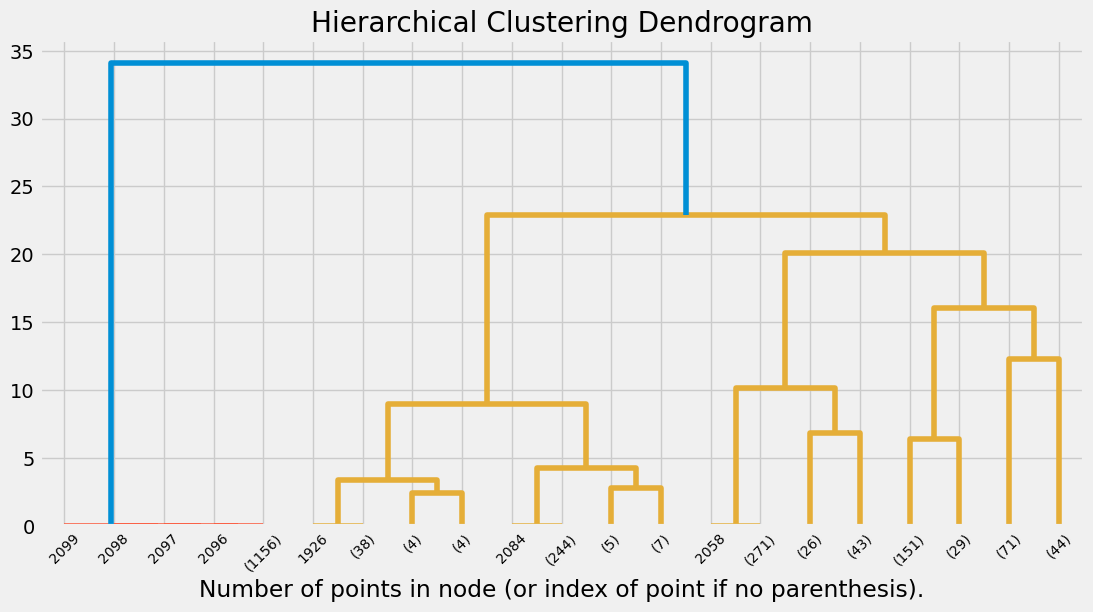

In [67]:
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(ward, truncate_mode="level", p=4)
plt.xlabel('Number of points in node (or index of point if no parenthesis).')
plt.show()

In [68]:
clustering_model5_who = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clustering_model5_who.fit(data_who_scaled)
clustering_model4_who = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
clustering_model4_who.fit(data_who_scaled)

AgglomerativeClustering(n_clusters=4)

In [69]:
db_score = davies_bouldin_score(data_who_scaled, clustering_model5_who.labels_)
print(f"Davies-Bouldin Index 5 clusters: {db_score:.3f}")
db_score = davies_bouldin_score(data_who_scaled, clustering_model4_who.labels_)
print(f"Davies-Bouldin Index 4 clusters: {db_score:.3f}")

Davies-Bouldin Index 5 clusters: 1.019
Davies-Bouldin Index 4 clusters: 1.039


In [70]:
data_who['HC_5'] = clustering_model5_who.labels_
unique, counts = np.unique(data_who.HC_5, return_counts=True) 
dict(zip(unique, counts))

{0: 115, 1: 341, 2: 304, 3: 1160, 4: 180}

In [71]:
data_who.groupby(['HC_5']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q29b_who_family                                      Q29b_who_neighbor  \
                mean       std  min  max median   q1   q3              mean   
HC_5                                                                          
0           0.365217  0.483598  0.0  1.0    0.0  0.0  1.0          0.426087   
1           0.073314  0.261034  0.0  1.0    0.0  0.0  0.0          0.032258   
2           0.154605  0.362124  0.0  1.0    0.0  0.0  0.0          1.000000   
3           1.000000  0.000000  1.0  1.0    1.0  1.0  1.0          0.000000   
4           0.138889  0.346795  0.0  1.0    0.0  0.0  0.0          0.000000   

                                          Q29b_who_colleague                 \
           std  min  max median   q1   q3               mean       std  min   
HC_5                                                                          
0     0.496671  0.0  1.0    0.0  0.0  1.0           0.373913  0.485958  0.0   
1     0.176944  0.0  1.0    0.0  0.0  0.0           0.035191  0.184532  0.0   
2     0.000000  1.0  1.0    1.0  1.0  1.0           0.042763  0.202656  0.0   
3     0.000000  0.0  0.0    0.0  0.0  0.0           0.000000  0.000000  0.0   
4     0.000000  0.0  0.0    0.0  0.0  0.0           1.000000  0.000000  1.0   

                           Q29b_who_online                                  \
      max median   q1   q3            mean       std  min  max median   q1   
HC_5                                                                         
0     1.0    0.0  0.0  1.0        1.000000  0.000000  1.0  1.0    1.0  1.0   
1     1.0    0.0  0.0  0.0        0.020528  0.142006  0.0  1.0    0.0  0.0   
2     1.0    0.0  0.0  0.0        0.013158  0.114139  0.0  1.0    0.0  0.0   
3     0.0    0.0  0.0  0.0        0.000000  0.000000  0.0  0.0    0.0  0.0   
4     1.0    1.0  1.0  1.0        0.005556  0.074536  0.0  1.0    0.0  0.0   

          Q29b_who_gov                                      Q29b_who_other  \
       q3         mean       std  min  max median   q1   q3           mean   
HC_5                                                                         
0     1.0     0.321739  0.469188  0.0  1.0    0.0  0.0  1.0       0.373913   
1     0.0     0.146628  0.354254  0.0  1.0    0.0  0.0  0.0       0.906158   
2     0.0     0.026316  0.160337  0.0  1.0    0.0  0.0  0.0       0.009868   
3     0.0     0.000000  0.000000  0.0  0.0    0.0  0.0  0.0       0.000000   
4     0.0     0.050000  0.218553  0.0  1.0    0.0  0.0  0.0       0.000000   

                                           
           std  min  max median   q1   q3  
HC_5                                       
0     0.485958  0.0  1.0    0.0  0.0  1.0  
1     0.292037  0.0  1.0    1.0  1.0  1.0  
2     0.099012  0.0  1.0    0.0  0.0  0.0  
3     0.000000  0.0  0.0    0.0  0.0  0.0  
4     0.000000  0.0  0.0    0.0  0.0  0.0

- cluster 0: online aquaintances, 32% government, 37% other, 37% collague, 42% neighbor, 37% family
- cluster 1: mainly other, 14% government, rest negligible
- cluster 2: neighbor (with some 15% also family, rest negligible)
- cluster 3: family & friends (only) --> by far biggest cluster
- cluster 4: colleagues (with some 14% also family/friends. rest negligible)

In [72]:
data_who['HC_4'] = clustering_model4_who.labels_
unique, counts = np.unique(data_who.HC_4, return_counts=True) 
dict(zip(unique, counts))

{0: 295, 1: 341, 2: 304, 3: 1160}

In [73]:
data_who.groupby(['HC_4']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q29b_who_family                                      Q29b_who_neighbor  \
                mean       std  min  max median   q1   q3              mean   
HC_4                                                                          
0           0.227119  0.419682  0.0  1.0    0.0  0.0  0.0          0.166102   
1           0.073314  0.261034  0.0  1.0    0.0  0.0  0.0          0.032258   
2           0.154605  0.362124  0.0  1.0    0.0  0.0  0.0          1.000000   
3           1.000000  0.000000  1.0  1.0    1.0  1.0  1.0          0.000000   

                                          Q29b_who_colleague                 \
           std  min  max median   q1   q3               mean       std  min   
HC_4                                                                          
0     0.372804  0.0  1.0    0.0  0.0  0.0           0.755932  0.430263  0.0   
1     0.176944  0.0  1.0    0.0  0.0  0.0           0.035191  0.184532  0.0   
2     0.000000  1.0  1.0    1.0  1.0  1.0           0.042763  0.202656  0.0   
3     0.000000  0.0  0.0    0.0  0.0  0.0           0.000000  0.000000  0.0   

                           Q29b_who_online                                  \
      max median   q1   q3            mean       std  min  max median   q1   
HC_4                                                                         
0     1.0    1.0  1.0  1.0        0.393220  0.489295  0.0  1.0    0.0  0.0   
1     1.0    0.0  0.0  0.0        0.020528  0.142006  0.0  1.0    0.0  0.0   
2     1.0    0.0  0.0  0.0        0.013158  0.114139  0.0  1.0    0.0  0.0   
3     0.0    0.0  0.0  0.0        0.000000  0.000000  0.0  0.0    0.0  0.0   

          Q29b_who_gov                                      Q29b_who_other  \
       q3         mean       std  min  max median   q1   q3           mean   
HC_4                                                                         
0     1.0     0.155932  0.363408  0.0  1.0    0.0  0.0  0.0       0.145763   
1     0.0     0.146628  0.354254  0.0  1.0    0.0  0.0  0.0       0.906158   
2     0.0     0.026316  0.160337  0.0  1.0    0.0  0.0  0.0       0.009868   
3     0.0     0.000000  0.000000  0.0  0.0    0.0  0.0  0.0       0.000000   

                                               HC_5                           \
           std  min  max median   q1   q3      mean       std min max median   
HC_4                                                                           
0     0.353468  0.0  1.0    0.0  0.0  0.0  2.440678  1.954162   0   4    4.0   
1     0.292037  0.0  1.0    1.0  1.0  1.0  1.000000  0.000000   1   1    1.0   
2     0.099012  0.0  1.0    0.0  0.0  0.0  2.000000  0.000000   2   2    2.0   
3     0.000000  0.0  0.0    0.0  0.0  0.0  3.000000  0.000000   3   3    3.0   

                
       q1   q3  
HC_4            
0     0.0  4.0  
1     1.0  1.0  
2     2.0  2.0  
3     3.0  3.0

- cluster 0: cluster 0, 1 from above combined: mixed: 15% family, 13% neighbors, 12% colleagues, 26% online, 20% gov, 77% other
- cluster 1: colleagues (with some 14% also family/friends. rest negligible)
- cluster 2: neighbor (with some 15% also family, rest negligible)
- cluster 3: family & friends (only) --> by far biggest cluster

#### Clustering over Similarity
Are there patterns in the similarity between the alter and ego?

In [74]:
data_similar = NG_data[['Q29c_similar_flood', 'Q29c_similar_house', 'Q29c_similar_edu', 'Q29c_similar_inc', 
                        'Q29c_similar_age']]
data_similar.head()

,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age
825,0.0,0.0,0.0,0.0,0.0
826,0.0,0.0,0.0,0.0,0.0
827,0.0,0.0,0.0,0.0,0.0
830,0.0,0.0,0.0,0.0,0.0
831,0.0,0.0,0.0,0.0,0.0


In [75]:
data_similar.describe()

,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,0.372381,0.340000,0.352857,0.236667,0.333810
std,0.483554,0.473822,0.477973,0.425137,0.471685
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [76]:
# scaling the data
data_similar_scaled = scaler.fit_transform(data_similar)
data_similar_scaled

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [77]:
ward = AgglomerativeClustering(linkage = 'ward',  n_clusters= None, distance_threshold = 0)
ward.fit(data_similar_scaled)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

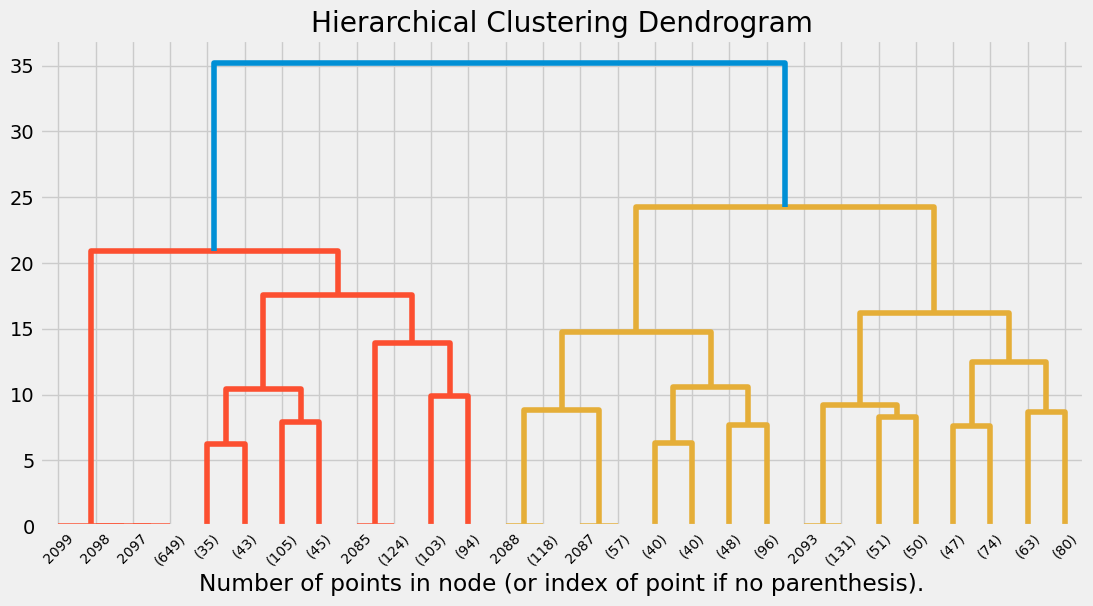

In [78]:
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(ward, truncate_mode="level", p=4)
plt.xlabel('Number of points in node (or index of point if no parenthesis).')
plt.show()

In [79]:
clustering_model3 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clustering_model3.fit(data_similar)
clustering_model4_similar = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
clustering_model4_similar.fit(data_similar)

AgglomerativeClustering(n_clusters=4)

In [80]:
db_score = davies_bouldin_score(data_similar_scaled, clustering_model3.labels_)
print(f"Davies-Bouldin Index 3 clusters: {db_score:.3f}")
db_score = davies_bouldin_score(data_similar_scaled, clustering_model4_similar.labels_)
print(f"Davies-Bouldin Index 4 clusters: {db_score:.3f}")

Davies-Bouldin Index 3 clusters: 1.510
Davies-Bouldin Index 4 clusters: 1.475


In [81]:
data_similar['HC_3'] = clustering_model3.labels_
unique, counts = np.unique(data_similar.HC_3, return_counts=True) 
dict(zip(unique, counts))

{0: 1202, 1: 497, 2: 401}

In [82]:
data_similar.groupby(['HC_3']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q29c_similar_flood                                       \
                   mean       std  min  max median   q1   q3   
HC_3                                                           
0              0.255408  0.436272  0.0  1.0    0.0  0.0  1.0   
1              0.585513  0.493130  0.0  1.0    1.0  0.0  1.0   
2              0.458853  0.498927  0.0  1.0    0.0  0.0  1.0   

     Q29c_similar_house                                      Q29c_similar_edu  \
                   mean       std  min  max median   q1   q3             mean   
HC_3                                                                            
0              0.228785  0.420226  0.0  1.0    0.0  0.0  0.0         0.189684   
1              0.593561  0.491663  0.0  1.0    1.0  0.0  1.0         0.712274   
2              0.359102  0.480337  0.0  1.0    0.0  0.0  1.0         0.396509   

                                          Q29c_similar_inc                 \
           std  min  max median   q1   q3             mean  std  min  max   
HC_3                                                                        
0     0.392214  0.0  1.0    0.0  0.0  0.0              0.0  0.0  0.0  0.0   
1     0.453159  0.0  1.0    1.0  0.0  1.0              1.0  0.0  1.0  1.0   
2     0.489783  0.0  1.0    0.0  0.0  1.0              0.0  0.0  0.0  0.0   

                      Q29c_similar_age                                       
     median   q1   q3             mean       std  min  max median   q1   q3  
HC_3                                                                         
0       0.0  0.0  0.0         0.000000  0.000000  0.0  0.0    0.0  0.0  0.0  
1       1.0  1.0  1.0         0.603622  0.489638  0.0  1.0    1.0  0.0  1.0  
2       0.0  0.0  0.0         1.000000  0.000000  1.0  1.0    1.0  1.0  1.0

- cluster 0: 20% similar education, none similar income, none similar age, 25% similar flood, 23% similar house
- cluster 1: 70% similar education, all similar income, 60% similar age, 60% similar flood, 60% similar house
- cluster 2: 40% similar education, none similar income, all similar age, 45% similar flood, 35% similar house

In [83]:
data_similar['HC_4'] = clustering_model4_similar.labels_
unique, counts = np.unique(data_similar.HC_4, return_counts=True) 
dict(zip(unique, counts))

{0: 550, 1: 497, 2: 401, 3: 652}

In [84]:
data_similar.groupby(['HC_4']).agg([ np.mean, np.std, np.min, np.max, np.median, q1, q3])

Q29c_similar_flood                                       \
                   mean       std  min  max median   q1   q3   
HC_4                                                           
0              0.558182  0.497055  0.0  1.0    1.0  0.0  1.0   
1              0.585513  0.493130  0.0  1.0    1.0  0.0  1.0   
2              0.458853  0.498927  0.0  1.0    0.0  0.0  1.0   
3              0.000000  0.000000  0.0  0.0    0.0  0.0  0.0   

     Q29c_similar_house                                      Q29c_similar_edu  \
                   mean       std  min  max median   q1   q3             mean   
HC_4                                                                            
0              0.500000  0.500455  0.0  1.0    0.5  0.0  1.0         0.414545   
1              0.593561  0.491663  0.0  1.0    1.0  0.0  1.0         0.712274   
2              0.359102  0.480337  0.0  1.0    0.0  0.0  1.0         0.396509   
3              0.000000  0.000000  0.0  0.0    0.0  0.0  0.0         0.000000   

                                          Q29c_similar_inc                 \
           std  min  max median   q1   q3             mean  std  min  max   
HC_4                                                                        
0     0.493092  0.0  1.0    0.0  0.0  1.0              0.0  0.0  0.0  0.0   
1     0.453159  0.0  1.0    1.0  0.0  1.0              1.0  0.0  1.0  1.0   
2     0.489783  0.0  1.0    0.0  0.0  1.0              0.0  0.0  0.0  0.0   
3     0.000000  0.0  0.0    0.0  0.0  0.0              0.0  0.0  0.0  0.0   

                      Q29c_similar_age                                       \
     median   q1   q3             mean       std  min  max median   q1   q3   
HC_4                                                                          
0       0.0  0.0  0.0         0.000000  0.000000  0.0  0.0    0.0  0.0  0.0   
1       1.0  1.0  1.0         0.603622  0.489638  0.0  1.0    1.0  0.0  1.0   
2       0.0  0.0  0.0         1.000000  0.000000  1.0  1.0    1.0  1.0  1.0   
3       0.0  0.0  0.0         0.000000  0.000000  0.0  0.0    0.0  0.0  0.0   

     HC_3                                
     mean  std min max median   q1   q3  
HC_4                                     
0     0.0  0.0   0   0    0.0  0.0  0.0  
1     1.0  0.0   1   1    1.0  1.0  1.0  
2     2.0  0.0   2   2    2.0  2.0  2.0  
3     0.0  0.0   0   0    0.0  0.0  0.0

cluster 0 from above splot
- cluster 0: 40% similar education, none similar income, none similar age, 55% similar flood, 50% similar house (26%)
- cluster 1: 70% similar education, all similar income, 60% similar age, 60% similar flood, 60% similar house  --> most homophilious (24%)
- cluster 2: 40% similar education, none similar income, all similar age, 45% similar flood, 35% similar house (19%)
- cluster 3: no similarities at all (31%)

#### Linking clustering results to all data

To fill the Table in Appendix E (table E2)

In [85]:
NG_data['4cluster_Q29b_who'] = clustering_model4_who.labels_
NG_data['4cluster_Q29c_similar'] = clustering_model4_similar.labels_
NG_data.head()

,country,ID,person,Q29a_adapt,Q29b_who_family,Q29b_who_neighbor,Q29b_who_colleague,Q29b_who_online,Q29b_who_gov,Q29b_who_other,Q29c_similar_flood,Q29c_similar_house,Q29c_similar_edu,Q29c_similar_inc,Q29c_similar_age,Q29c_similar_none,Q29d_distance,Q29e_com_street,Q29e_com_call,Q29e_com_gatherings,Q29e_com_work,Q29e_com_other,Q29f_com_freq,Q29g_flood_com_freq,Q29h_com_what_cause,Q29h_com_what_measures,Q29h_com_what_community,Q29h_com_what_gov_react,Q29h_com_what_gov_adapt,Q29h_com_what_livability,Q29h_com_what_other,Q29i_worry,Q29j_valuable_exp,4cluster_Q29b_who,4cluster_Q29c_similar
825,UK,2,1,98.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,5.0,0,3
826,UK,2,2,98.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,5.0,0,3
827,UK,2,3,98.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,98.0,0.0,0.0,0.0,0.0,1.0,5.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,98.0,3.0,1,3
830,UK,5,1,98.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,1.0,4.0,3,3
831,UK,5,2,98.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,1.0,3.0,3,3


In [86]:
NG_data_no_country = NG_data.drop(columns = ['country', 'person', 'ID'])
NG_data_no_country_dist_idk_removed = NG_data_no_country[(NG_data_no_country.Q29d_distance != 98)]
NG_data_no_country_dist_idk_removed.groupby(['4cluster_Q29b_who']).agg([np.mean, np.std])

Q29a_adapt            Q29b_who_family            \
                        mean        std            mean       std   
4cluster_Q29b_who                                                   
0                  33.044355  46.164400        0.193548  0.395878   
1                  31.796610  45.823810        0.161017  0.369114   
2                  26.975177  43.608123        0.145390  0.353120   
3                  22.368468  40.975437        1.000000  0.000000   

                  Q29b_who_neighbor           Q29b_who_colleague            \
                               mean       std               mean       std   
4cluster_Q29b_who                                                            
0                          0.112903  0.317114           0.762097  0.426661   
1                          0.076271  0.266563           0.076271  0.266563   
2                          1.000000  0.000000           0.042553  0.202206   
3                          0.000000  0.000000           0.000000  0.000000   

                  Q29b_who_online           Q29b_who_gov            \
                             mean       std         mean       std   
4cluster_Q29b_who                                                    
0                        0.342742  0.475586     0.108871  0.312107   
1                        0.042373  0.202297     0.322034  0.469248   
2                        0.014184  0.118461     0.021277  0.144561   
3                        0.000000  0.000000     0.000000  0.000000   

                  Q29b_who_other           Q29c_similar_flood            \
                            mean       std               mean       std   
4cluster_Q29b_who                                                         
0                       0.092742  0.290657           0.310484  0.463627   
1                       0.805085  0.397825           0.262712  0.441984   
2                       0.010638  0.102774           0.602837  0.490180   
3                       0.000000  0.000000           0.430469  0.495361   

                  Q29c_similar_house           Q29c_similar_edu            \
                                mean       std             mean       std   
4cluster_Q29b_who                                                           
0                           0.302419  0.460235         0.387097  0.488071   
1                           0.203390  0.404237         0.245763  0.432374   
2                           0.648936  0.478151         0.400709  0.490913   
3                           0.372011  0.483555         0.436670  0.496193   

                  Q29c_similar_inc           Q29c_similar_age            \
                              mean       std             mean       std   
4cluster_Q29b_who                                                         
0                         0.266129  0.442826         0.306452  0.461952   
1                         0.194915  0.397825         0.220339  0.416243   
2                         0.294326  0.456549         0.400709  0.490913   
3                         0.279008  0.448710         0.418069  0.493460   

                  Q29c_similar_none           Q29d_distance            \
                               mean       std          mean       std   
4cluster_Q29b_who                                                       
0                          0.237903  0.426661      3.016129  1.275645   
1                          0.474576  0.501483      2.983051  1.383561   
2                          0.141844  0.349510      1.386525  0.866269   
3                          0.188663  0.391414      2.751107  1.489639   

                  Q29e_com_street           Q29e_com_call            \
                             mean       std          mean       std   
4cluster_Q29b_who                                                     
0                        0.133065  0.340331      0.250000  0.433888   
1                        0.118644  0.324748      0.372881  0.485633   
2                        0.634752  0.

In [87]:
ng_clWHO_country = NG_data.groupby(['country', '4cluster_Q29b_who']).agg([np.mean, np.std])
ng_clWHO_country.drop(columns = ['ID', 'person'])

Q29a_adapt            Q29b_who_family            \
                                mean        std            mean       std   
country 4cluster_Q29b_who                                                   
UK      0                  36.781818  47.407347        0.209091  0.408521   
        1                  44.126582  48.823579        0.056962  0.232507   
        2                  35.162791  46.963548        0.131783  0.339573   
        3                  27.985138  44.197644        1.000000  0.000000   
US      0                  45.582090  49.010249        0.208955  0.409631   
        1                  39.075269  48.156953        0.032258  0.177642   
        2                  25.932039  43.167313        0.203883  0.404853   
        3                  19.585185  38.954858        1.000000  0.000000   
NL      0                  31.720339  45.876252        0.254237  0.437288   
        1                  31.711111  45.963406        0.144444  0.353509   
        2                  21.888889  40.969778        0.125000  0.333040   
        3                  20.105634  39.531480        1.000000  0.000000   

                          Q29b_who_neighbor           Q29b_who_colleague  \
                                       mean       std               mean   
country 4cluster_Q29b_who                                                  
UK      0                          0.154545  0.363125           0.790909   
        1                          0.044304  0.206423           0.044304   
        2                          1.000000  0.000000           0.038760   
        3                          0.000000  0.000000           0.000000   
US      0                          0.044776  0.208373           0.805970   
        1                          0.021505  0.145848           0.000000   
        2                          1.000000  0.000000           0.038835   
        3                          0.000000  0.000000           0.000000   
NL      0                          0.245763  0.432374           0.694915   
        1                          0.022222  0.148231           0.055556   
        2                          1.000000  0.000000           0.055556   
        3                          0.000000  0.000000           0.000000   

                                    Q29b_who_online           Q29b_who_gov  \
                                std            mean       std         mean   
country 4cluster_Q29b_who                                                    
UK      0                  0.408521        0.345455  0.477693     0.136364   
        1                  0.206423        0.025316  0.157584     0.132911   
        2                  0.193774        0.007752  0.088045     0.031008   
        3                  0.000000        0.000000  0.000000     0.000000   
US      0                  0.398437        0.253731  0.438430     0.044776   
        1                  0.000000        0.000000  0.000000     0.021505   
        2                  0.194146        0.009709  0.098533     0.000000   
        3                  0.000000        0.000000  0.000000     0.000000   
NL      0                  0.462407        0.516949  0.501844     0.237288   
        1                  0.230345        0.033333  0.180511     0.300000   
        2                  0.230669        0.027778  0.165489     0.055556   
        3                  0.000000        0.000000  0.000000     0.000000   

                                    Q29b_who_other            \
                                std           mean       std   
country 4cluster_Q29b_who                                      
UK      0                  0.344745       0.100000  0.301373   
        1                  0.340558       0.905063  0.294060   
        2                  0.174014       0.000000  0.000000   
        3                  0.000000       0.000000  0.000000   
US      0                  0.208373       0.044776  0.208373   
        1                  0.145848       0.98

In [88]:
NG_data.groupby(['country', '4cluster_Q29b_who']).count()

ID  person  Q29a_adapt  Q29b_who_family  \
country 4cluster_Q29b_who                                             
UK      0                  110     110         110              110   
        1                  158     158         158              158   
        2                  129     129         129              129   
        3                  471     471         471              471   
US      0                   67      67          67               67   
        1                   93      93          93               93   
        2                  103     103         103              103   
        3                  405     405         405              405   
NL      0                  118     118         118              118   
        1                   90      90          90               90   
        2                   72      72          72               72   
        3                  284     284         284              284   

                           Q29b_who_neighbor  Q29b_who_colleague  \
country 4cluster_Q29b_who                                          
UK      0                                110                 110   
        1                                158                 158   
        2                                129                 129   
        3                                471                 471   
US      0                                 67                  67   
        1                                 93                  93   
        2                                103                 103   
        3                                405                 405   
NL      0                                118                 118   
        1                                 90                  90   
        2                                 72                  72   
        3                                284                 284   

                           Q29b_who_online  Q29b_who_gov  Q29b_who_other  \
country 4cluster_Q29b_who                                                  
UK      0                              110           110             110   
        1                              158           158             158   
        2                              129           129             129   
        3                              471           471             471   
US      0                               67            67              67   
        1                               93            93              93   
        2                              103           103             103   
        3                              405           405             405   
NL      0                              118           118             118   
        1                               90            90              90   
        2                               72            72              72   
        3                              284           284             284   

                           Q29c_similar_flood  Q29c_similar_house  \
country 4cluster_Q29b_who                                           
UK      0                                 110                 110   
        1                                 158                 158   
        2                                 129                 129   
        3                                 471                 471   
US      0                                  67                  67   
        1                                  93                  93   
        2                                 103                 103   
        3                                 405                 405   
NL      0                                 118                 118   
        1                                  90                  90   
        2                                  72                  72   
        3                                 284                 284   

                           Q29c_similar_edu  Q29

In [89]:
ng_clSimilar_country = NG_data.groupby(['country', '4cluster_Q29c_similar']).agg([np.mean, np.std])
ng_clWHO_country.drop(columns = ['ID', 'person'])

Q29a_adapt            Q29b_who_family            \
                                mean        std            mean       std   
country 4cluster_Q29b_who                                                   
UK      0                  36.781818  47.407347        0.209091  0.408521   
        1                  44.126582  48.823579        0.056962  0.232507   
        2                  35.162791  46.963548        0.131783  0.339573   
        3                  27.985138  44.197644        1.000000  0.000000   
US      0                  45.582090  49.010249        0.208955  0.409631   
        1                  39.075269  48.156953        0.032258  0.177642   
        2                  25.932039  43.167313        0.203883  0.404853   
        3                  19.585185  38.954858        1.000000  0.000000   
NL      0                  31.720339  45.876252        0.254237  0.437288   
        1                  31.711111  45.963406        0.144444  0.353509   
        2                  21.888889  40.969778        0.125000  0.333040   
        3                  20.105634  39.531480        1.000000  0.000000   

                          Q29b_who_neighbor           Q29b_who_colleague  \
                                       mean       std               mean   
country 4cluster_Q29b_who                                                  
UK      0                          0.154545  0.363125           0.790909   
        1                          0.044304  0.206423           0.044304   
        2                          1.000000  0.000000           0.038760   
        3                          0.000000  0.000000           0.000000   
US      0                          0.044776  0.208373           0.805970   
        1                          0.021505  0.145848           0.000000   
        2                          1.000000  0.000000           0.038835   
        3                          0.000000  0.000000           0.000000   
NL      0                          0.245763  0.432374           0.694915   
        1                          0.022222  0.148231           0.055556   
        2                          1.000000  0.000000           0.055556   
        3                          0.000000  0.000000           0.000000   

                                    Q29b_who_online           Q29b_who_gov  \
                                std            mean       std         mean   
country 4cluster_Q29b_who                                                    
UK      0                  0.408521        0.345455  0.477693     0.136364   
        1                  0.206423        0.025316  0.157584     0.132911   
        2                  0.193774        0.007752  0.088045     0.031008   
        3                  0.000000        0.000000  0.000000     0.000000   
US      0                  0.398437        0.253731  0.438430     0.044776   
        1                  0.000000        0.000000  0.000000     0.021505   
        2                  0.194146        0.009709  0.098533     0.000000   
        3                  0.000000        0.000000  0.000000     0.000000   
NL      0                  0.462407        0.516949  0.501844     0.237288   
        1                  0.230345        0.033333  0.180511     0.300000   
        2                  0.230669        0.027778  0.165489     0.055556   
        3                  0.000000        0.000000  0.000000     0.000000   

                                    Q29b_who_other            \
                                std           mean       std   
country 4cluster_Q29b_who                                      
UK      0                  0.344745       0.100000  0.301373   
        1                  0.340558       0.905063  0.294060   
        2                  0.174014       0.000000  0.000000   
        3                  0.000000       0.000000  0.000000   
US      0                  0.208373       0.044776  0.208373   
        1                  0.145848       0.98

In [90]:
NG_data.groupby(['country', '4cluster_Q29c_similar']).count()

ID  person  Q29a_adapt  Q29b_who_family  \
country 4cluster_Q29c_similar                                             
UK      0                      203     203         203              203   
        1                      201     201         201              201   
        2                      170     170         170              170   
        3                      294     294         294              294   
US      0                      194     194         194              194   
        1                      182     182         182              182   
        2                      145     145         145              145   
        3                      147     147         147              147   
NL      0                      153     153         153              153   
        1                      114     114         114              114   
        2                       86      86          86               86   
        3                      211     211         211              211   

                               Q29b_who_neighbor  Q29b_who_colleague  \
country 4cluster_Q29c_similar                                          
UK      0                                    203                 203   
        1                                    201                 201   
        2                                    170                 170   
        3                                    294                 294   
US      0                                    194                 194   
        1                                    182                 182   
        2                                    145                 145   
        3                                    147                 147   
NL      0                                    153                 153   
        1                                    114                 114   
        2                                     86                  86   
        3                                    211                 211   

                               Q29b_who_online  Q29b_who_gov  Q29b_who_other  \
country 4cluster_Q29c_similar                                                  
UK      0                                  203           203             203   
        1                                  201           201             201   
        2                                  170           170             170   
        3                                  294           294             294   
US      0                                  194           194             194   
        1                                  182           182             182   
        2                                  145           145             145   
        3                                  147           147             147   
NL      0                                  153           153             153   
        1                                  114           114             114   
        2                                   86            86              86   
        3                                  211           211             211   

                               Q29c_similar_flood  Q29c_similar_house  \
country 4cluster_Q29c_similar                                           
UK      0                                     203                 203   
        1                                     201                 201   
        2                                     170                 170   
        3                                     294                 294   
US      0                                     194                 194   
        1                                     182                 182   
        2                                     145                 145   
        3                                     147                 147   
NL      0                                     153                 153   
        1                                     11

In [91]:
NG_data.groupby(['4cluster_Q29b_who', '4cluster_Q29c_similar', 'country']).count()

ID  person  Q29a_adapt  \
4cluster_Q29b_who 4cluster_Q29c_similar country                            
0                 0                     UK        28      28          28   
                                        US        23      23          23   
                                        NL        35      35          35   
                  1                     UK        20      20          20   
                                        US        15      15          15   
                                        NL        33      33          33   
                  2                     UK        21      21          21   
                                        US        11      11          11   
                                        NL        16      16          16   
                  3                     UK        41      41          41   
                                        US        18      18          18   
                                        NL        34      34          34   
1                 0                     UK        13      13          13   
                                        US         6       6           6   
                                        NL        10      10          10   
                  1                     UK        10      10          10   
                                        US         6       6           6   
                                        NL        12      12          12   
                  2                     UK         3       3           3   
                                        US         7       7           7   
                                        NL         7       7           7   
                  3                     UK       132     132         132   
                                        US        74      74          74   
                                        NL        61      61          61   
2                 0                     UK        45      45          45   
                                        US        36      36          36   
                                        NL        22      22          22   
                  1                     UK        39      39          39   
                                        US        37      37          37   
                                        NL         9       9           9   
                  2                     UK        24      24          24   
                                        US        23      23          23   
                                        NL        13      13          13   
                  3                     UK        21      21          21   
                                        US         7       7           7   
                                        NL        28      28          28   
3                 0                     UK       117     117         117   
                                        US       129     129         129   
                                        NL        86      86          86   
                  1                     UK       132     132         132   
                                        US       124     124         124   
                                        NL        60      60          60   
                  2                     UK       122     122         122   
                                        US       104     104         104   
                                        NL        50      50          50   
                  3                     UK       100     100         100   
                                        US        48      48          48   
                                        NL        88      88          88   

                                                 Q29b_who_family  \
4cluster_Q29b_who 4cluster_Q29c_similar country                    
0                 0                     UK                    28   
                                        US   